<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️TIF Análisis de Detección de Intrusiones en Red

**Grupo 1**: Gonza Gabriela · Casasola Hernán · Biazutti Luciano · Lera Aníbal Iván · Alvarado Marcelo

**Módulo**: Ciencias de Datos y Optimización de Modelos

**Carrera**: Tecnicatura Universitaria en Ciencias de Datos e IA Aplicada — UPATECO

---

# 1. Comprensión del problema

## 1.1 Contexto

Las redes informáticas son blanco constante de ataques como denegación de servicio (DoS), escaneo de puertos o infiltraciones. Detectarlos a tiempo es crítico para proteger la infraestructura, y hacerlo manualmente es inviable a escala. 

Para resolver este problema usamos el dataset **CIC-IDS-2017**, desarrollado por el Canadian Institute for Cybersecurity. Contiene 2,8 millones de flujos de red capturados durante 5 días en un entorno controlado, etiquetados como tráfico normal y ataques como Brute Force, Heartbleed, Botnet, DoS, DDoS, Web Attack e Infiltración.

## 1.2 Definición del Problema

**¿Qué problema queremos resolver con estos datos?**

Dado un flujo de red con sus métricas (duración, bytes, paquetes, intervalos de tiempo, etc.), queremos determinar automáticamente si ese tráfico es **benigno o un ataque**, y en caso de ser un ataque, **qué tipo** de ataque es.

| Ítem | Detalle |
|---|---|
| **Problema** | Clasificar tráfico de red como benigno o malicioso |
| **Tipo** | Clasificación supervisada multiclase |
| **Variable objetivo** | Label (BENIGN, DoS, DDoS, PortScan, etc.) |
| **Objetivo** | Detectar intrusiones con alta precisión y recall |
| **Impacto** | Permite automatizar la detección de ataques en tiempo real |
||

**¿Por qué elegimos este dataset?**

Porque es un dataset real y complejo que permite practicar todo el flujo de Ciencia de Datos: tiene variables numéricas y una variable objetivo clara, contiene problemas reales de calidad de datos y el problema que resuelve de seguridad informática es relevante.


## 1.3 Ficha del dataset

| Campo | Descripción |
| :--- | :--- |
| **Nombre** | CICIDS2017 — Network Intrusion Dataset |
| **Institución creadora** | Canadian Institute for Cybersecurity (CIC) — University of New Brunswick |
| **Propósito** | Desarrollo y evaluación de sistemas de detección de intrusiones (IDS/NIDS) |
| **Mecanismo de recolección** | Captura de tráfico de red real durante 5 días con **CICFlowMeter** (extrae features de flujos TCP/UDP) |
| **Registros** | 2.830.743 |
| **Variables** | 78 variables numéricas + 1 variable categórica `Label` |
| **Documentación de cada variable** |[📖 Diccionario de Datos](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/diccionario_de_datos.md) |
|  | [🛡️ Diccionario de Clases y Tipos de Ataques](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/clase_label.md) |
| **Fuentes** | [Kaggle](https://www.kaggle.com/datasets/cicdataset/cicids2017) · [UNB oficial](https://www.unb.ca/cic/datasets/ids-2017.html) |
| **Restricciones de uso** | Libre para uso académico e investigación |

## 1.4 Problemas conocidos del dataset

* **Tamaño del archivo**: 2,8M de filas puede ser lento en máquinas locales. Nosotros vamos a trabajar con archivos .parquet ya que optimiza el almacenamiento mediante una estructura columnar que maximiza la compresión y acelera las consultas al leer solo los datos necesarios.

* **Valores infinitos**: las variables Flow Bytes/s y Flow Packets/s contienen np.inf. Convertirlos a NaN y decidir si eliminamos esas filas o imputarles un valor promedio.

* **Desbalance severo de clases**: BENIGN representa ~80% de los registros. Requiere estrategia de balanceo.

# 2. Comprensión de los datos

## 2.1 Librerías y Configuración

In [ ]:
import os
import glob
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

!pip install session_info
import session_info

warnings.filterwarnings('ignore')

# Definición de colores para gráficos
COLOR_BENIGNO = '#A1D99B'   # Verde pastel
COLOR_ATAQUE  = '#F8766D'   # Rojo pastel
COLOR_NEUTRO  = '#AED6F1'   # Azul pastel

## 2.2 Lectura del dataset

In [ ]:
# Montar en Drive
from google.colab import drive
drive.mount('/content/drive')

# Rutas principales
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/Dataset'
CHECKPOINT_DIR = '/content/drive/MyDrive/Colab Notebooks/Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f'Dataset en: {DATA_DIR}')
print(f'Checkpoints en: {CHECKPOINT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset en: /content/drive/MyDrive/Colab Notebooks/Dataset
Checkpoints en: /content/drive/MyDrive/Colab Notebooks/Checkpoints


In [ ]:
# Cargar checkpoint sección 3
ruta_ckpt_s3 = f'{CHECKPOINT_DIR}/dataset_checkpoint_sec3.parquet'

CHECKPOINT_CARGADO = False

if os.path.exists(ruta_ckpt_s3):
    df = pd.read_parquet(ruta_ckpt_s3)
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    CHECKPOINT_CARGADO = True
    print('Checkpoint de sección 3 cargado.')
    print(f'Filas: {df.shape[0]:,} Columnas: {df.shape[1]}')
    print('Podés saltar hasta la Sección 4.')
else:
    print('No se encontró checkpoint. Continuá con la carga del dataset.')

Checkpoint de sección 3 cargado.
Filas: 2,827,876 Columnas: 64
Podés saltar hasta la Sección 4.


In [ ]:
# Carga del Dataset (saltar si cargaste checkpoint)

# Buscar todos los archivos .parquet
parquet_files = glob.glob(os.path.join(DATA_DIR, '*.parquet'))

# Unir todos los archivos en uno solo
dfs_list = []
for file in parquet_files:
    df_temp = pd.read_parquet(file)
    dfs_list.append(df_temp)

df = pd.concat(dfs_list, ignore_index=True)

# Limpieza básica de nombres de columnas
df.columns = df.columns.str.strip()

# Limpieza de caracteres raros en las etiquetas
df['Label'] = df['Label'].str.replace(r'[^\w\s-]', '-', regex=True)

print(f'Dataset cargado con {df.shape[0]:,} filas y con {df.shape[1]} columnas.')

Dataset cargado con 2,830,743 filas y con 79 columnas.


In [ ]:
# Vista rápida de las primeras filas
pd.set_option('display.float_format', '{:.2f}'.format)
df.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.00,0.00,...,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.00,0.00,...,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.00,0.00,...,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN


In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [ ]:
# Tipos de variables
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print(f'Variables numéricas: {len(num_cols)}')
print(f'Variables categóricas: {cat_cols}')

Variables numéricas: 78
Variables categóricas: ['Label']


**Respuestas**

**¿Cuántas filas y columnas hay?** El dataset contiene 2.830.743 filas y 79 columnas.

**¿Qué tipos de datos aparecen?** Predominan variables numéricas (78) y una variable categórica (Label).

**¿Cómo se distribuyen las variables?**
* Numéricas discretas: 54 variables (int64).
* Numéricas continuas: 24 variables (float64).
* Categórica nominal: 1 variable (object), correspondiente a la columna Label.

**¿Qué representa cada fila del dataset?**
Cada registro es un flujo de red completo: el conjunto de todos los paquetes intercambiados entre dos direcciones IP durante una conexión. No es un paquete individual sino el resumen estadístico de toda la comunicación.

## 2.3 Identificación de la variable objetivo

In [ ]:
# Conteo y porcentaje por clase
counts = df['Label'].value_counts()
pcts   = counts / counts.sum() * 100

resumen_clases = pd.DataFrame({
    'Cantidad'      : counts,
    'Porcentaje (%)': pcts.round(3),
    'Tipo'          : ['Benigno' if c == 'BENIGN' else 'Ataque' for c in counts.index]
})
print(resumen_clases.to_string())

                            Cantidad  Porcentaje (%)     Tipo
Label                                                        
BENIGN                       2273097          80.300  Benigno
DoS Hulk                      231073           8.163   Ataque
PortScan                      158930           5.614   Ataque
DDoS                          128027           4.523   Ataque
DoS GoldenEye                  10293           0.364   Ataque
FTP-Patator                     7938           0.280   Ataque
SSH-Patator                     5897           0.208   Ataque
DoS slowloris                   5796           0.205   Ataque
DoS Slowhttptest                5499           0.194   Ataque
Bot                             1966           0.069   Ataque
Web Attack - Brute Force        1507           0.053   Ataque
Web Attack - XSS                 652           0.023   Ataque
Infiltration                      36           0.001   Ataque
Web Attack - Sql Injection        21           0.001   Ataque
Heartble

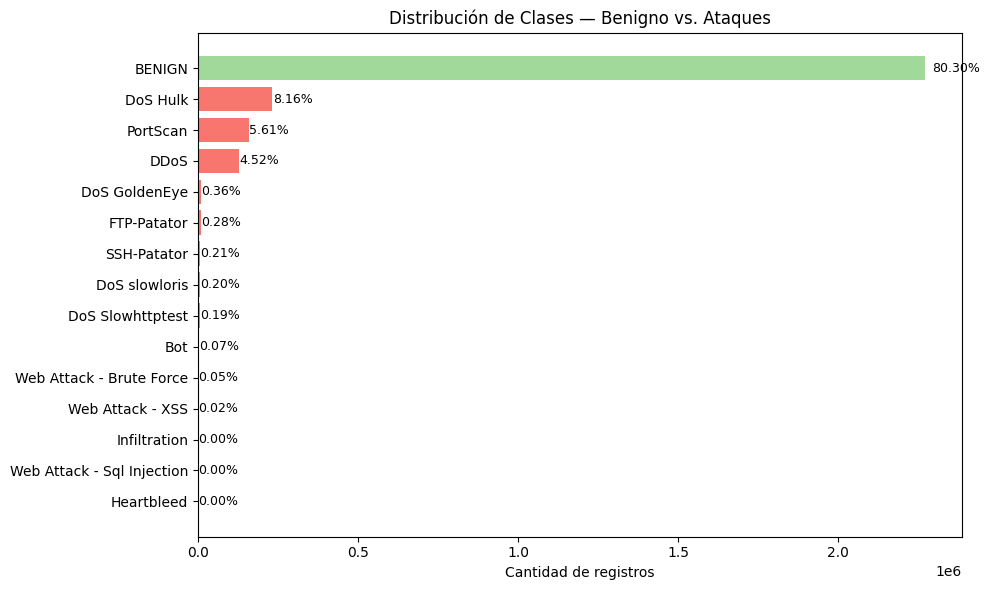

In [ ]:
# Gráfico: distribución de clases
colors = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(counts.index, counts.values, color=colors)

# Etiqueta con porcentaje al final de cada barra
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f'{pct:.2f}%', va='center', fontsize=9)

ax.set_xlabel('Cantidad de registros')
ax.set_title('Distribución de Clases — Benigno vs. Ataques')
ax.invert_yaxis() # la clase más frecuente arriba
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

**Respuestas**

**¿Cuál es la variable objetivo?**
La variable objetivo es Label, que indica si el tráfico es benigno o un tipo especícico de ataque.

**¿Hay múltiples clases?**
Sí, es un problema multiclase, incluye beningn más 14 tipos de ataques distintos.

**¿Está balanceado el dataset?**
El dataset está desbalanceado, ya que la clase BENIGN representa el 80% de los datos.

**¿Qué ataques dominan?**
Los 3 ataques más frecuentes son: DoS Hulk, PortScan y DDoS. Mientras que Heartbleed, Web Attack-Sql Injection	o Infiltration son extremadamente raros.


## 2.4 Estadísticas descriptivas

In [ ]:
# Estadísticos completos
# Desactivar notación científica y mostrar números normales
pd.set_option('display.float_format', '{:.2f}'.format)

# Calcular estadísticos base
desc = df[num_cols].describe().T

# Métricas adicionales útiles para el EDA
desc['mediana'] = df[num_cols].median()
desc['sesgo'] = df[num_cols].skew()
desc['curtosis'] = df[num_cols].kurtosis()
desc['%_ceros'] = (df[num_cols] == 0).mean() * 100
desc['%_nan'] = df[num_cols].isnull().mean() * 100

# Ordenar por sesgo
desc_sorted = desc.sort_values('sesgo', ascending=False)

print(desc_sorted[['count', 'mean', 'mediana', 'std', 'min',
                    '25%', '75%', 'max', 'sesgo', 'curtosis',
                    '%_ceros', '%_nan']].to_string())

                                 count        mean  mediana         std             min    25%        75%           max    sesgo   curtosis  %_ceros  %_nan
Total Length of Fwd Packets 2827876.00      549.85    62.00     9998.64            0.00  12.00     188.00   12900000.00   805.17  987557.16    15.83   0.00
Subflow Fwd Bytes           2827876.00      549.84    62.00     9985.11            0.00  12.00     188.00   12870338.00   803.20  983890.78    15.83   0.00
act_data_pkt_fwd            2827876.00        5.42     1.00      636.75            0.00   0.00       2.00     213557.00   284.45   82992.53    33.97   0.00
Subflow Bwd Packets         2827876.00       10.40     2.00      997.89            0.00   1.00       4.00     291922.00   244.56   61955.16    15.97   0.00
Total Backward Packets      2827876.00       10.40     2.00      997.89            0.00   1.00       4.00     291922.00   244.56   61955.16    15.97   0.00
Total Fwd Packets           2827876.00        9.37     2.00     

In [ ]:
# Guardar la tabla descriptiva
desc_sorted.to_csv(f'{CHECKPOINT_DIR}/estadisticos_descriptivos.csv')
print('Tabla guardada en: Checkpoints/estadisticos_descriptivos.csv')

Tabla guardada en: Checkpoints/estadisticos_descriptivos.csv


**Respuestas**

**¿Cómo se distribuyen las variables?**

Las variables presentan alta dispersión, distribuciones sesgadas (no normales) y valores extremos en varias columnas.

En variables como Total Length of Bwd Packets, la desviación estándar 2,263,088$ es significativamente superior a la media 16,162, lo que indica una variabilidad extrema. Además, la diferencia entre el valor mínimo 0 y el máximo 655,453,030 refuerza la existencia de datos muy heterogéneos.

Esta dispersión es natural en ciberseguridad, ya que el tráfico normal suele ser pequeño y constante, mientras que ciertos ataques o transferencias masivas generan esos picos extremos que disparan la desviación estándar.

**¿Qué variable presenta el mayor volumen de datos transmitidos en promedio?**

La variable Total Length of Bwd Packets con un promedio de 16,162 bytes por flujo, supera ampliamente a los paquetes enviados (Forward), que promedian 549.30 bytes.

**¿Cuál es la diferencia entre el promedio y la mediana en la variable Total Length of Bwd Packets?**

Hay una diferencia enorme, el promedio es 16,162.64 mientras que la mediana es solo 123.0. Esto indica una distribución extremadamente sesgada donde unos pocos flujos tienen tamaños gigantescos.

En datos de tráfico de red tan sesgados, la mediana describe mucho mejor lo que ocurre en la mayoría de las conexiones.

**¿Cómo se comporta el sesgo en el dataset?**

Todas las variables muestran un sesgo positivo alto (valores como 805.57 o 244.38). Esto confirma que la gran mayoría de las conexiones de red son pequeñas, pero existe una "cola" larga hacia la derecha de eventos con valores muy altos (posibles ataques o transferencias masivas).

**¿Qué indica el valor de curtosis tan elevado en variables como Total Length of Fwd Packets?**

La curtosis de 988,552.61 indica una distribución "Leptocúrtica" extrema. Esto significa que los datos tienen una concentración altísima en un punto y presentan valores atípicos (outliers) muy severos y frecuentes.

**¿Qué indican un sesgo y curtosis alto?**

Cuando una variable tiene sesgo alto y curtosis alta al mismo tiempo, como ocurre en la mayoría de las variables de este dataset, significa que hay muchísimas conexiones pequeñas y normales, más unos pocos eventos extremos muy alejados del resto. Para un IDS, esos eventos extremos son exactamente los que queremos detectar.

**¿Qué relación hay entre el sesgo de las variables y el desbalance de clases?**

Ambos fenómenos están relacionados. Como BENIGN representa el 80% del dataset, la mayoría de los registros corresponden a tráfico normal con valores pequeños y estables. Los ataques, aunque pocos en cantidad, generan los valores extremos que producen el sesgo positivo. Si el dataset estuviera balanceado, el sesgo sería menor porque habría más registros con valores altos.

**¿Qué variable tiene la mayor cantidad de valores en cero y qué significa esto?**

La variable Fwd URG Flags tiene un 99.98% de ceros. En ciberseguridad, esto es normal ya que las "flags" de urgencia no se usan con frecuencia en el tráfico común; su aparición podría ser un indicador importante para detectar tipos específicos de anomalías o escaneos.

**¿Existe presencia de valores nulos en las variables analizadas?**

Según la columna %_nan, todas las variables mostradas tienen un 0.0% de valores nulos, vamos a profundizar en el análisis para confirmar.

## 2.5 Detección y Tratamiento de Valores infinitos

In [ ]:
# Ver columnas con valores infinitos
inf_por_columna = np.isinf(df[num_cols]).sum()
inf_detectados  = inf_por_columna[inf_por_columna > 0]

print(f'Columnas con valores infinitos: {len(inf_detectados)}')
print(inf_detectados)

Columnas con valores infinitos: 2
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [ ]:
#Reemplazar loa valores infinitos por NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print('Valores infinitos reemplazados por NaN.')

Valores infinitos reemplazados por NaN.


## 2.6 Valores faltantes (NaN)

In [ ]:
# Mostrar columnas con NaN
nan_counts = df.isnull().sum()
nan_cols   = nan_counts[nan_counts > 0]

print(f'Columnas con NaN: {len(nan_cols)}')
print(nan_cols)
print(f'\nTotal de NaN en el dataset: {nan_cols.sum():,}')
print(f'Representan el {nan_cols.sum() / df.size * 100:.4f}% del total de celdas.')

Columnas con NaN: 2
Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64

Total de NaN en el dataset: 5,734
Representan el 0.0026% del total de celdas.


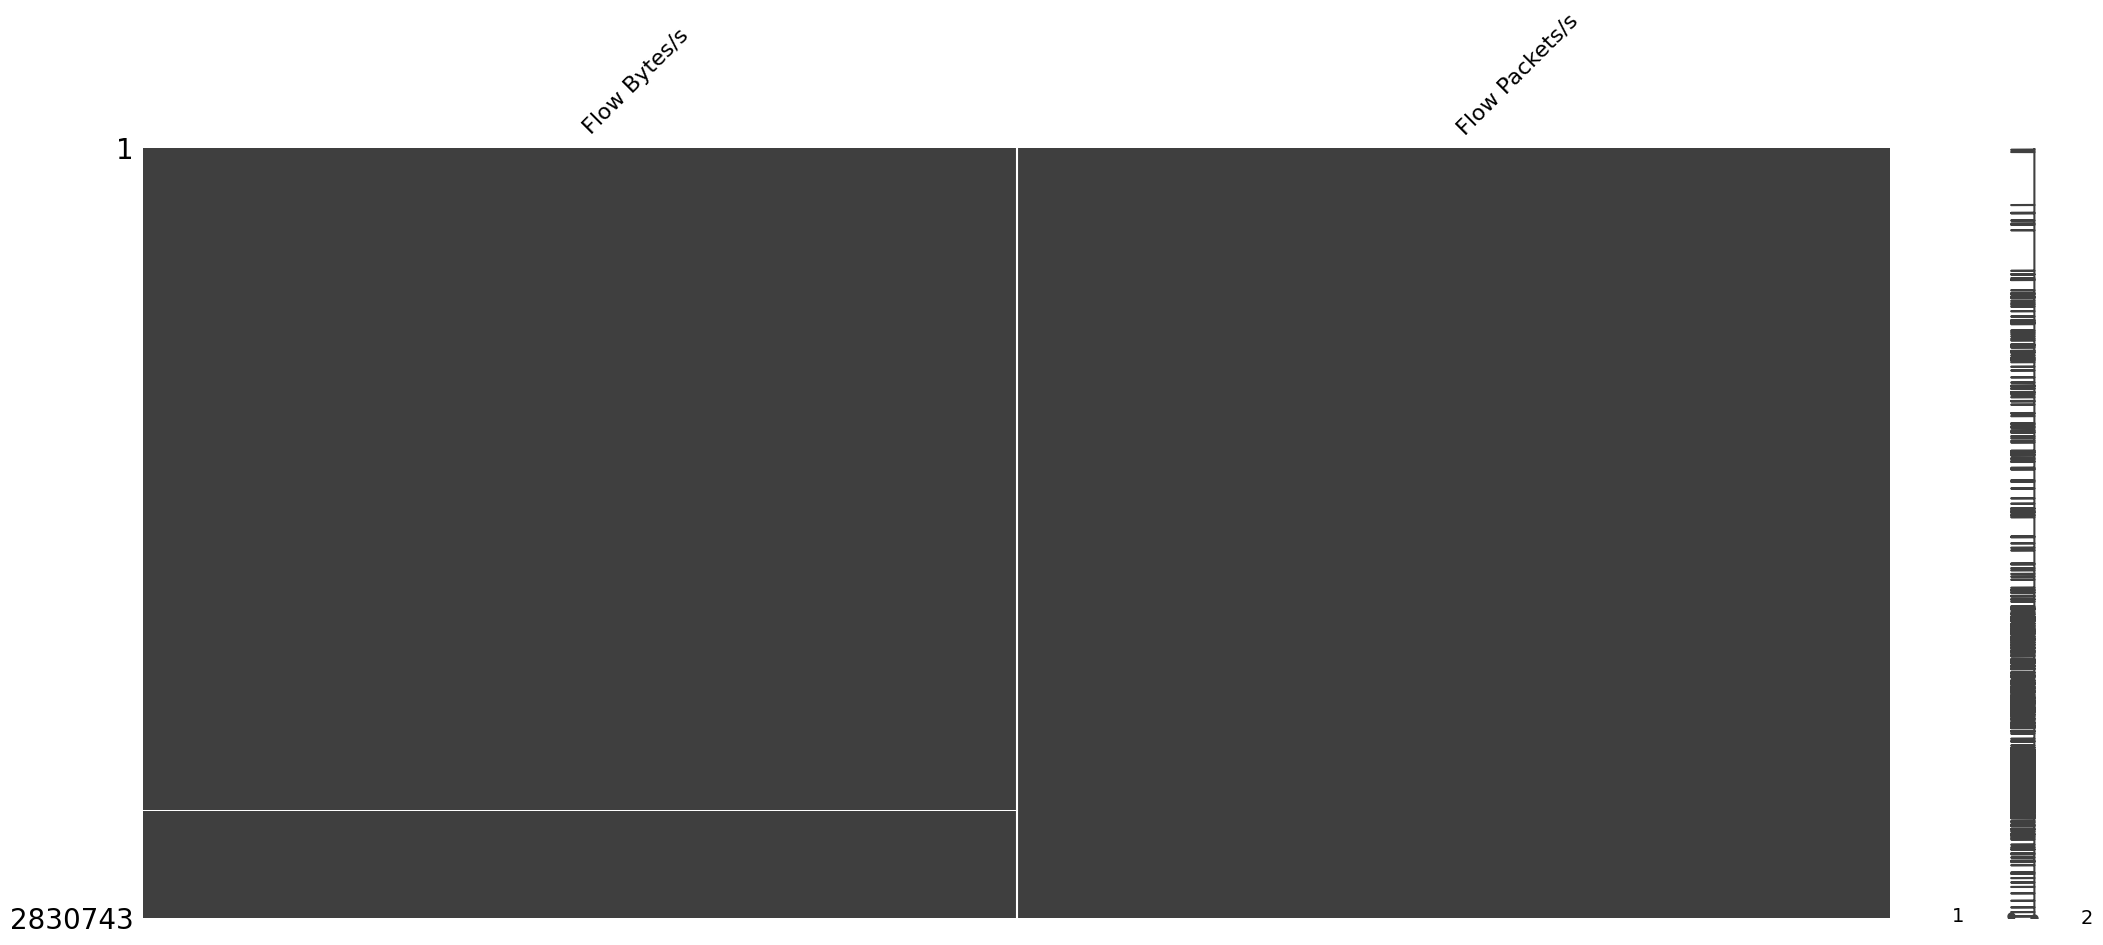

In [ ]:
# Visualizar la ubicación de los NaN
msno.matrix(df[['Flow Bytes/s', 'Flow Packets/s']])

plt.savefig(f'{CHECKPOINT_DIR}/grafico_nan.png', dpi=150, bbox_inches='tight')

In [ ]:
# Decisión: eliminar filas con NaN
filas_antes  = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
filas_despues = len(df)

print(f'Filas eliminadas: {filas_antes - filas_despues:,}')
print(f'Dataset final: {filas_despues:,} filas')
print(f'NaN restantes: {df.isnull().sum().sum()}')

Filas eliminadas: 2,867
Dataset final: 2,827,876 filas
NaN restantes: 0


**Respuestas**

**¿Hay valores raros?**

Sí, existen valores infinitos (np.inf) en variables como: Flow Bytes/s y Flow Packets/s.
Estos deben tratarse antes de modelar.


**¿Hay valores faltantes?**

Sí, existen valores faltantes de la variable Flow Bytes/s y Flow Packets/s.

**¿Qué tipo son?**

Es altamente probable que sean MAR (Missing at Random) ya que ambos tienen exactamente el mismo número de nulos (2,867). Esto indica que el error no es aleatorio; cuando falla el cálculo de "bytes por segundo", también falla el de "paquetes por segundo".

En este dataset específico, esos NaN suelen ocurrir cuando la duración del flujo (Flow Duration) es 0. Al calcular una tasa (Bytes / Duración), la división por cero genera un valor indefinido.

**¿Qué estrategia de limpieza se justifica?**

Dado que representan solo el 0.0026% del dataset, la estrategia más eficiente y segura es la eliminación de estos registros (dropping), ya que no se pierde información significativa y se evita introducir sesgos mediante imputaciones en variables de red tan sensibles.



## 2.7 Análisis de Outliers

In [ ]:
# Método IQR para detectar outliers
Q1  = df[num_cols].quantile(0.25)
Q3  = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_count = ((df[num_cols] < limite_inferior) | (df[num_cols] > limite_superior)).sum()
outliers_pct = (outliers_count / len(df) * 100).round(2)

outliers_df = pd.DataFrame({
    'n_outliers': outliers_count,
    'pct_outliers': outliers_pct
}).sort_values('pct_outliers', ascending=False)

print(outliers_df.head(20).to_string())
print(f'\nVariables con > 10% outliers: {(outliers_pct > 10).sum()}')
print(f'Variables con > 20% outliers: {(outliers_pct > 20).sum()}')

                             n_outliers  pct_outliers
Fwd IAT Mean                     670680         23.72
Fwd IAT Max                      665495         23.53
Fwd IAT Total                    665187         23.52
Fwd Packet Length Max            664211         23.49
Fwd Packet Length Std            663957         23.48
Fwd IAT Std                      659997         23.34
Bwd Packet Length Std            653968         23.13
Packet Length Variance           654086         23.13
Bwd Packet Length Max            637019         22.53
Destination Port                 625966         22.14
Max Packet Length                623427         22.05
Subflow Bwd Bytes                619005         21.89
Total Length of Bwd Packets      619005         21.89
Bwd IAT Std                      598847         21.18
Flow IAT Std                     598096         21.15
Flow IAT Mean                    572650         20.25
Bwd IAT Max                      567858         20.08
Idle Max                    

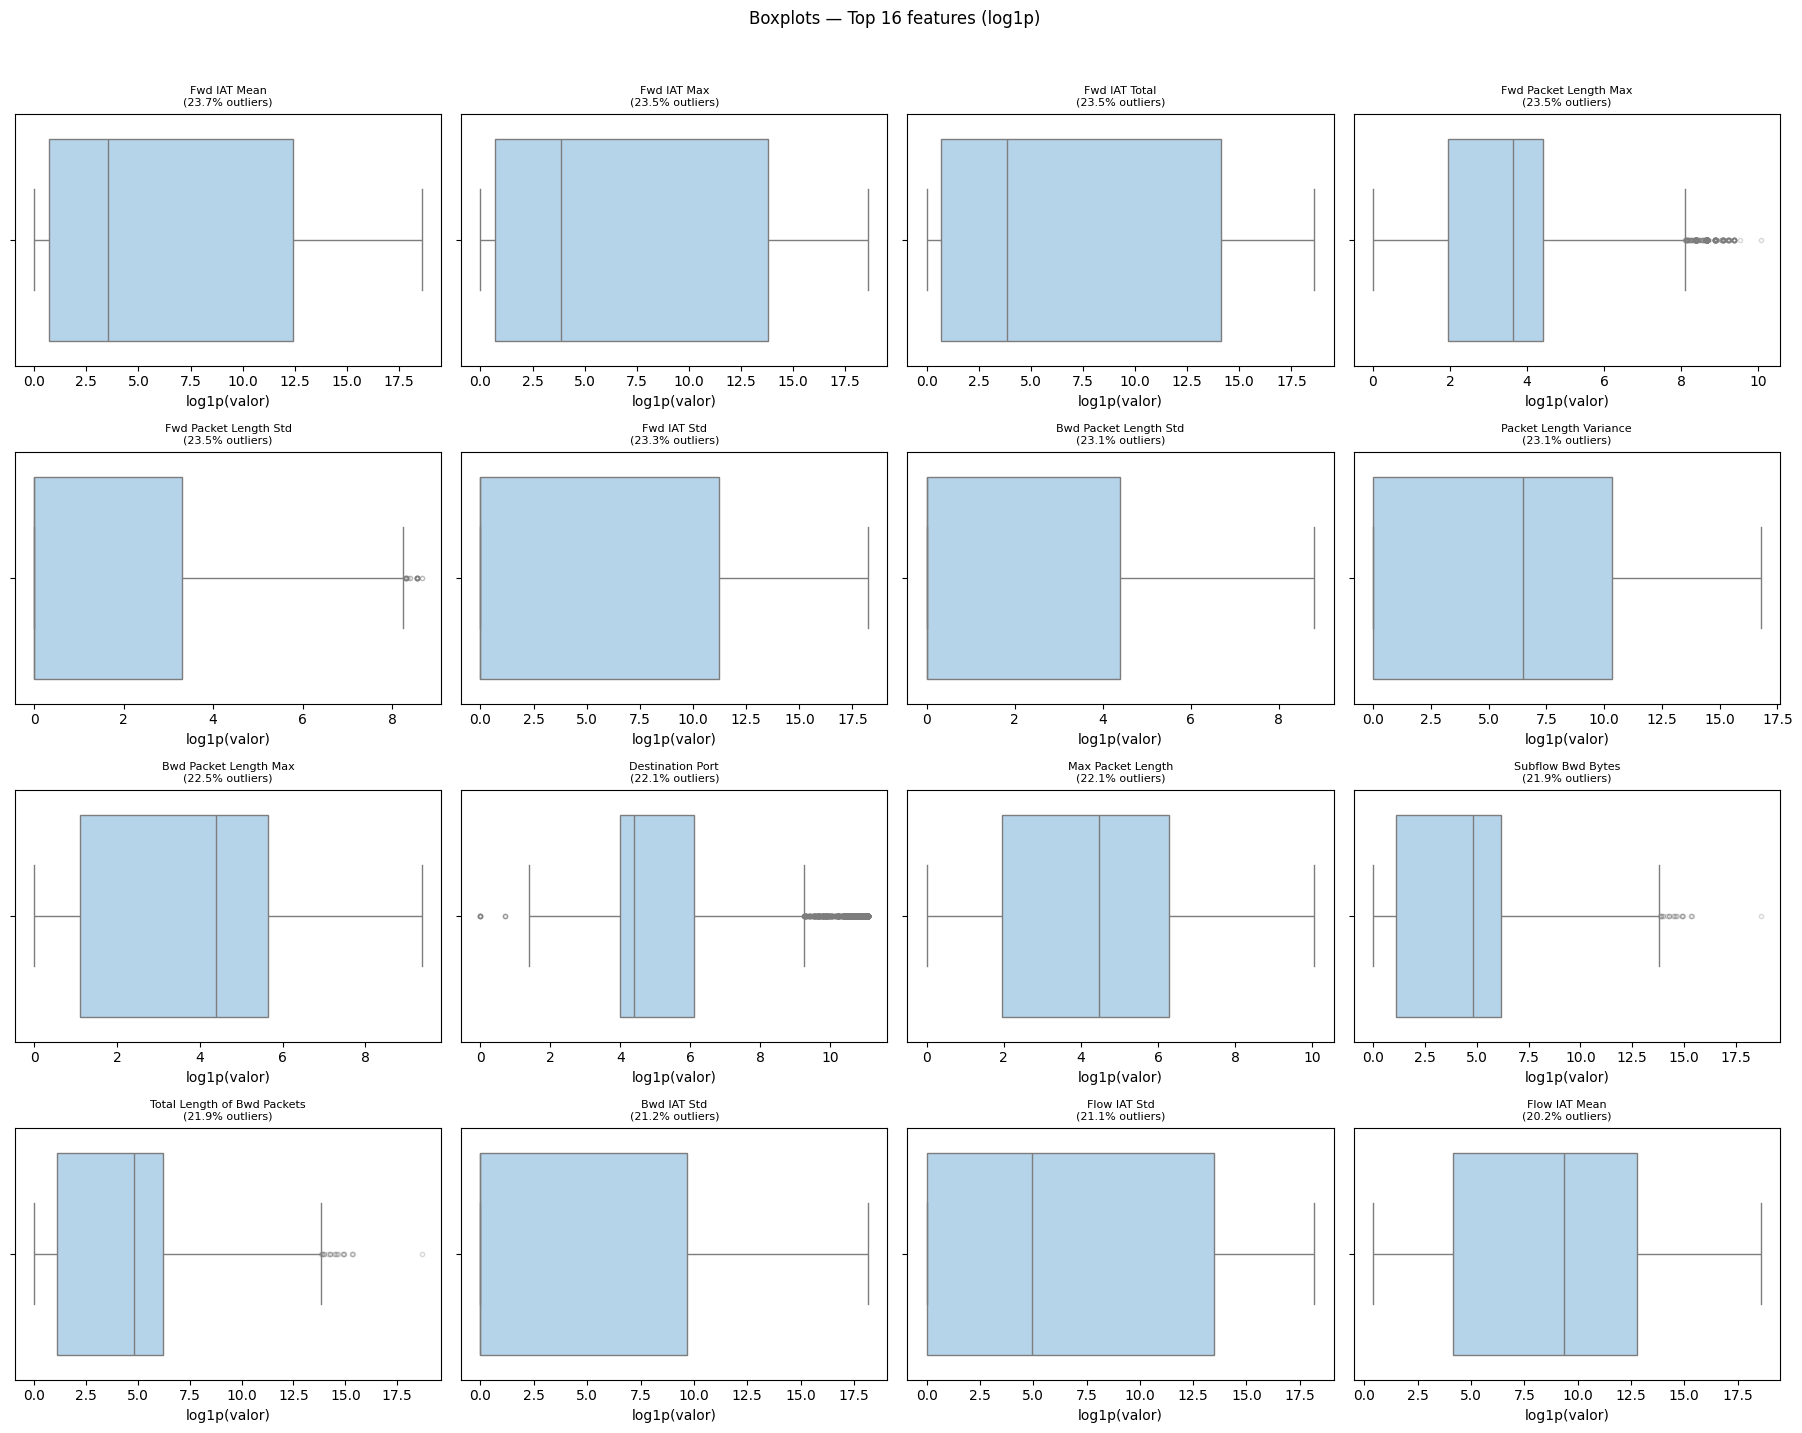

In [ ]:
# Visualizamos las 16 con mayor proporción de outliers

# Preparación compacta de datos
cols = outliers_df.head(16).index.tolist()
muestra = df[num_cols].sample(min(30000, len(df)), random_state=42).apply(np.log1p)

# Configuración del gráfico con Seaborn
plt.figure(figsize=(18, 14))
for i, col in enumerate(cols):
    ax = plt.subplot(4, 4, i + 1)
    sns.boxplot(data=muestra[col], orient='h', color=COLOR_NEUTRO,
                flierprops={'marker': '.', 'alpha': 0.3})

    ax.set_title(f"{col}\n({outliers_pct[col]:.1f}% outliers)", fontsize=8)
    ax.set(xlabel='log1p(valor)')

plt.suptitle('Boxplots — Top 16 Variables (log1p)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

**Respuestas**

**¿Qué son los outliers en este contexto?**

Son flujos de red con valores extremadamente altos o bajos en alguna métrica. En redes, un ataque DoS genera millones de paquetes por segundo deliberadamente, así que los "outliers" no son errores sino señales de ataque.

**¿Cuántas variables tienen outliers significativos?**

La mayoría de las 78 variables presentan outliers, con varias superando el 20 % de sus valores fuera del rango IQR.

**¿Los eliminamos?**

No, los outliers son **información valiosa**, no ruido. Eliminarlos podría borrar justamente los patrones que distinguen un ataque del tráfico normal.

# 3. Limpieza y Calidad del Dataset

## 3.1 Detección de Variables Problemáticas

In [ ]:
# Variables constantes (varianza = 0)
# Si una columna tiene el mismo valor en todas las filas, no aporta nada al modelo
rango = df[num_cols].max() - df[num_cols].min()
constantes = rango[rango == 0].index.tolist()

print(f'Variables constantes encontradas: {len(constantes)}')
for col in constantes:
    print(f' {col}: valor único = {df[col].unique()[0]}')

Variables constantes encontradas: 8
 Bwd PSH Flags: valor único = 0
 Bwd URG Flags: valor único = 0
 Fwd Avg Bytes/Bulk: valor único = 0
 Fwd Avg Packets/Bulk: valor único = 0
 Fwd Avg Bulk Rate: valor único = 0
 Bwd Avg Bytes/Bulk: valor único = 0
 Bwd Avg Packets/Bulk: valor único = 0
 Bwd Avg Bulk Rate: valor único = 0


In [ ]:
# Variables con alta proporción de ceros (>50 %)
pct_ceros = (df[num_cols] == 0).mean() * 100
muchos_ceros = pct_ceros[pct_ceros > 50].sort_values(ascending=False)

print(f'Variables con > 50 % de ceros: {len(muchos_ceros)}')
print(muchos_ceros.to_string())

Variables con > 50 % de ceros: 31
Bwd PSH Flags           100.00
Bwd URG Flags           100.00
Bwd Avg Packets/Bulk    100.00
Fwd Avg Bulk Rate       100.00
Bwd Avg Bytes/Bulk      100.00
Fwd Avg Bytes/Bulk      100.00
Fwd Avg Packets/Bulk    100.00
Bwd Avg Bulk Rate       100.00
CWE Flag Count           99.99
Fwd URG Flags            99.99
RST Flag Count           99.98
ECE Flag Count           99.98
FIN Flag Count           96.47
Fwd PSH Flags            95.36
SYN Flag Count           95.36
Active Std               92.73
Idle Std                 91.89
URG Flag Count           90.52
Active Max               80.24
Active Min               80.24
Active Mean              80.24
Idle Max                 79.94
Idle Mean                79.94
Idle Min                 79.94
Bwd Packet Length Std    71.56
Bwd IAT Std              71.30
PSH Flag Count           70.17
ACK Flag Count           68.47
Fwd Packet Length Std    65.35
Fwd IAT Std              62.71
Bwd Packet Length Min    50.77


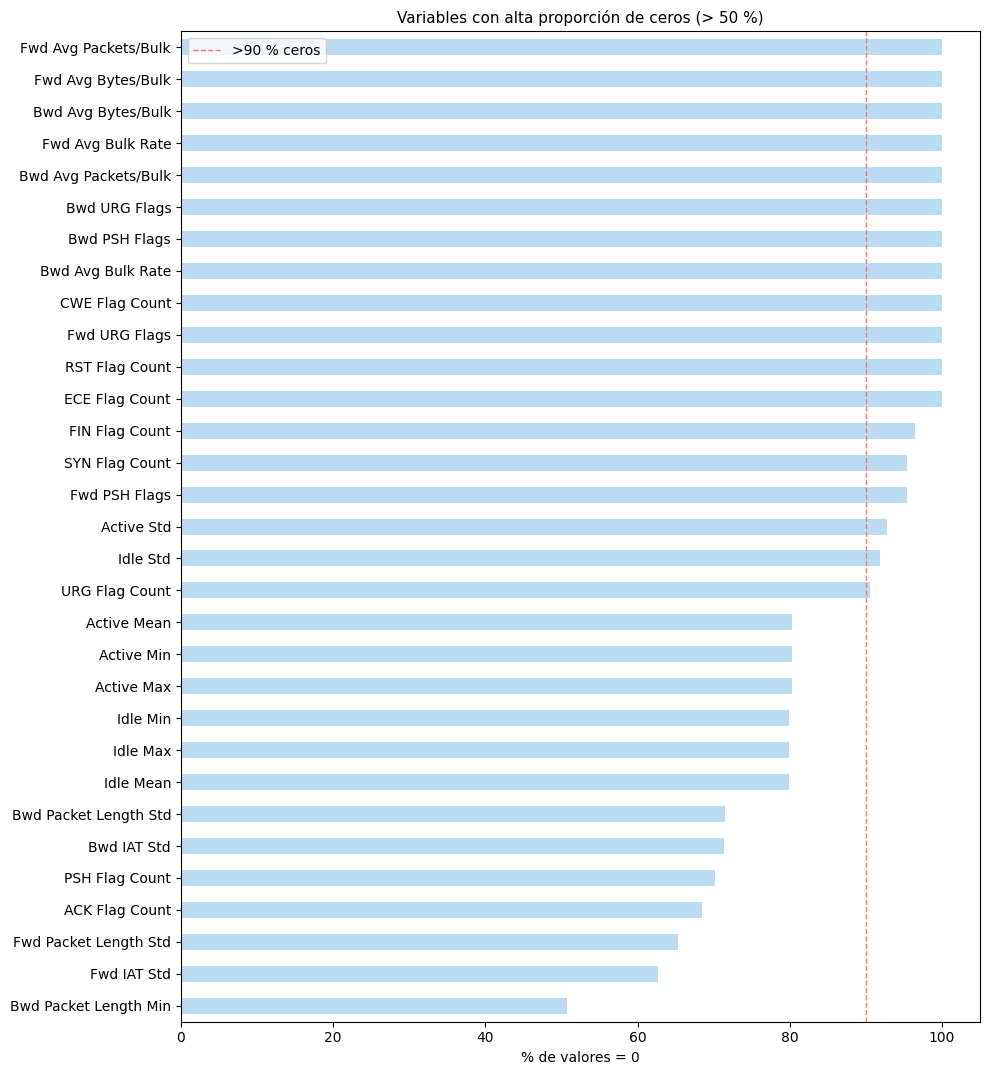

In [ ]:
# Visualización: Variables con muchos ceros
if not muchos_ceros.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(muchos_ceros) * 0.35)))
    muchos_ceros.sort_values().plot(kind='barh', ax=ax, color=COLOR_NEUTRO, alpha=0.85)
    ax.axvline(x=90, color=COLOR_ATAQUE, linestyle='--', linewidth=1, label='>90 % ceros')
    ax.set_xlabel('% de valores = 0')
    ax.set_title('Variables con alta proporción de ceros (> 50 %)', fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/grafico_features_con_ceros.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Variables con valores negativos inesperados
# En tráfico de red: duración, bytes y paquetes nunca deben ser negativos

negativos = {}
for col in num_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        negativos[col] = {'n_negativos': n_neg, 'valor_min': df[col].min()}

print('Variables con valores negativos:')
if negativos:
    print(pd.DataFrame(negativos).T.to_string())
    print('\nVerificar si son errores de medición.')
else:
    print('Ninguna variable tiene valores negativos.')

Variables con valores negativos:
                         n_negativos       valor_min
Flow Duration                 115.00          -13.00
Flow Bytes/s                   85.00   -261000000.00
Flow Packets/s                115.00     -2000000.00
Flow IAT Mean                 115.00          -13.00
Flow IAT Max                  115.00          -13.00
Flow IAT Min                 2890.00          -14.00
Fwd IAT Min                    17.00          -12.00
Fwd Header Length              35.00 -32212234632.00
Bwd Header Length              22.00  -1073741320.00
Fwd Header Length.1            35.00 -32212234632.00
Init_Win_bytes_forward    1001172.00           -1.00
Init_Win_bytes_backward   1439672.00           -1.00
min_seg_size_forward           35.00   -536870661.00

Verificar si son errores de medición.


In [ ]:
# Pares de Variables idénticas
# Si dos columnas tienen exactamente los mismos valores, una es redundante

print('Buscando columnas con contenido idéntico...')

hashes_cols = {}
duplicados_encontrados = []

for col in num_cols:
    # Usamos el hash de los bytes del array para comparación rápida
    h = hash(df[col].values.tobytes())
    if h in hashes_cols:
        duplicados_encontrados.append((hashes_cols[h], col))
        print(f'Idénticas: "{hashes_cols[h]}"  ==  "{col}"')
    else:
        hashes_cols[h] = col

if not duplicados_encontrados:
    print('No se encontraron columnas con valores exactamente iguales.')

Buscando columnas con contenido idéntico...
Idénticas: "Bwd PSH Flags"  ==  "Bwd URG Flags"
Idénticas: "Fwd PSH Flags"  ==  "SYN Flag Count"
Idénticas: "Fwd URG Flags"  ==  "CWE Flag Count"
Idénticas: "Fwd Header Length"  ==  "Fwd Header Length.1"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Bytes/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Packets/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Fwd Avg Bulk Rate"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Bytes/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Packets/Bulk"
Idénticas: "Bwd PSH Flags"  ==  "Bwd Avg Bulk Rate"
Idénticas: "Total Fwd Packets"  ==  "Subflow Fwd Packets"
Idénticas: "Total Backward Packets"  ==  "Subflow Bwd Packets"


**Conclusiones del Análisis**

Tenemos los siguientes problemas críticos que afectan la calidad de los datos para el entrenamiento de un modelo:

* **Redundancia Absoluta (Varianza Cero)**: Existen 8 columnas constantes (como Bwd PSH Flags y Fwd Avg Bulk Rate) que contienen el mismo valor 0 en todas las filas.  
* **Alta Proporción de Ceros**: Existen 31 variables donde más del 50% de los datos son ceros.
* **Inconsistencias Físicas (Valores Negativos)**: Existen valores negativos en variables donde no debería, como Flow Duration (duración), Flow Bytes/s y Header Length, esto sugiere errores de medición.  
* **Columnas duplicadas**: Existen varias columnas idénticas entre sí, como Fwd PSH Flags y SYN Flag Count, o las versiones duplicadas de Fwd Header Length.

**DECISIÓN**: Realizar una limpieza de columnas.

1. Eliminar Columnas Constantes
2. Columnas Duplicadas: vamos a quedarnos con una sola versión de los pares idénticos.
3. Variables con Valores Negativos Críticos:
    * Si los valores negativos son pocos, eliminarmos solo esas filas o reemplazarlos por el valor absoluto/mediana.
    * Si una columna tiene valores negativos muy extremos (como Fwd Header Length con $-32,212,234,632.00$), es mejor descartar la columna, ya que el dato es erroneo.

## 3.2 Eliminación de Columnas Problemáticas

In [ ]:
# Definir columnas a eliminar por categorías
cols_constantes = constantes  # Las 8 identificadas con rango cero
cols_duplicadas = [
    'Fwd Header Length.1',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'SYN Flag Count',
    'CWE Flag Count'
]
# Eliminamos las que tienen errores de medición graves
cols_corruptas = ['Fwd Header Length', 'Bwd Header Length']

# Consolidar lista total de eliminación (sin duplicar nombres)
to_drop = list(set(cols_constantes + cols_duplicadas + cols_corruptas))

# Ejecutar la eliminación
df_clean = df.drop(columns=to_drop)

# Reporte de cambios
print(f"Limpieza completada.")
print(f"  - Columnas originales: {df.shape[1]}")
print(f"  - Columnas eliminadas: {len(to_drop)}")
print(f"  - Columnas restantes: {df_clean.shape[1]}")
print("\nVariables eliminadas:", *sorted(to_drop), sep="\n")

# Actualizar num_cols para futuros análisis
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

Limpieza completada.
  - Columnas originales: 79
  - Columnas eliminadas: 15
  - Columnas restantes: 64

Variables eliminadas:
Bwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Header Length
Bwd PSH Flags
Bwd URG Flags
CWE Flag Count
Fwd Avg Bulk Rate
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Header Length
Fwd Header Length.1
SYN Flag Count
Subflow Bwd Packets
Subflow Fwd Packets


In [ ]:
# Guardar checkpoint
ruta_parquet = f'{CHECKPOINT_DIR}/dataset_checkpoint_sec3.parquet'
ruta_meta = f'{CHECKPOINT_DIR}/metadatos_limpieza.txt'

# Guardar Dataset
df_clean.to_parquet(ruta_parquet, index=False)

# Guardar Metadatos de la sesión
with open(ruta_meta, 'w') as f:
    f.write(f"Fecha: {datetime.datetime.now()}\n")
    f.write(f"Columnas finales: {df_clean.shape[1]}\n")
    f.write(f"Filas finales: {df_clean.shape[0]:,}\n")
    f.write(f"Variables eliminadas: {len(to_drop)}\n")
    f.write(f"Target balance (BENIGN %): {(df_clean['Label'] == 'BENIGN').mean()*100:.2f}%")

# Verificación
df_verify = pd.read_parquet(ruta_parquet)
print(f'Dataset guardado: {ruta_parquet}')
print(f'Dimensiones: {df_verify.shape[0]:,} filas × {df_verify.shape[1]} columnas')
print(f'Tamaño disco: {os.path.getsize(ruta_parquet) / 1024**2:.1f} MB')

Dataset guardado: /content/drive/MyDrive/Colab Notebooks/Checkpoints/dataset_checkpoint_sec3.parquet
Dimensiones: 2,827,876 filas × 64 columnas
Tamaño disco: 308.7 MB


# 4. Análisis Exploratorio Profundo (EDA)

A partir de aquí usamos `df_clean`. Al reiniciar la sesión, debemos ejecutar las tres primeras celdas, hasta la celda de checkpoint de la sección 2.1 para cargar el dataset limpio.

In [ ]:
# Cargar df_clean si no está en memoria
if 'df_clean' not in dir():
    ruta = f'{CHECKPOINT_DIR}/dataset_checkpoint_sec3.parquet'
    df_clean = pd.read_parquet(ruta)
    num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
    print(f'Dataset cargado: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')
else:
    num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
    print('df_clean ya esta en memoria.')

Dataset cargado: 2,827,876 filas × 64 columnas


## 4.1 Distribución de Clases

In [ ]:
# Tabla de distribución con conteo y porcentaje
counts = df_clean['Label'].value_counts()
pcts   = counts / len(df_clean) * 100

tabla = pd.DataFrame({
    'Cantidad': counts,
    'Porcentaje (%)': pcts.round(3),
    'Tipo': ['Benigno' if c == 'BENIGN' else 'Ataque' for c in counts.index]
})
print(tabla.to_string())

                            Cantidad  Porcentaje (%)     Tipo
Label                                                        
BENIGN                       2271320           80.32  Benigno
DoS Hulk                      230124            8.14   Ataque
PortScan                      158804            5.62   Ataque
DDoS                          128025            4.53   Ataque
DoS GoldenEye                  10293            0.36   Ataque
FTP-Patator                     7935            0.28   Ataque
SSH-Patator                     5897            0.21   Ataque
DoS slowloris                   5796            0.20   Ataque
DoS Slowhttptest                5499            0.19   Ataque
Bot                             1956            0.07   Ataque
Web Attack - Brute Force        1507            0.05   Ataque
Web Attack - XSS                 652            0.02   Ataque
Infiltration                      36            0.00   Ataque
Web Attack - Sql Injection        21            0.00   Ataque
Heartble

## 4.2 ¿Cuánto dura cada Tipo de Ataque? (Flow Duration)

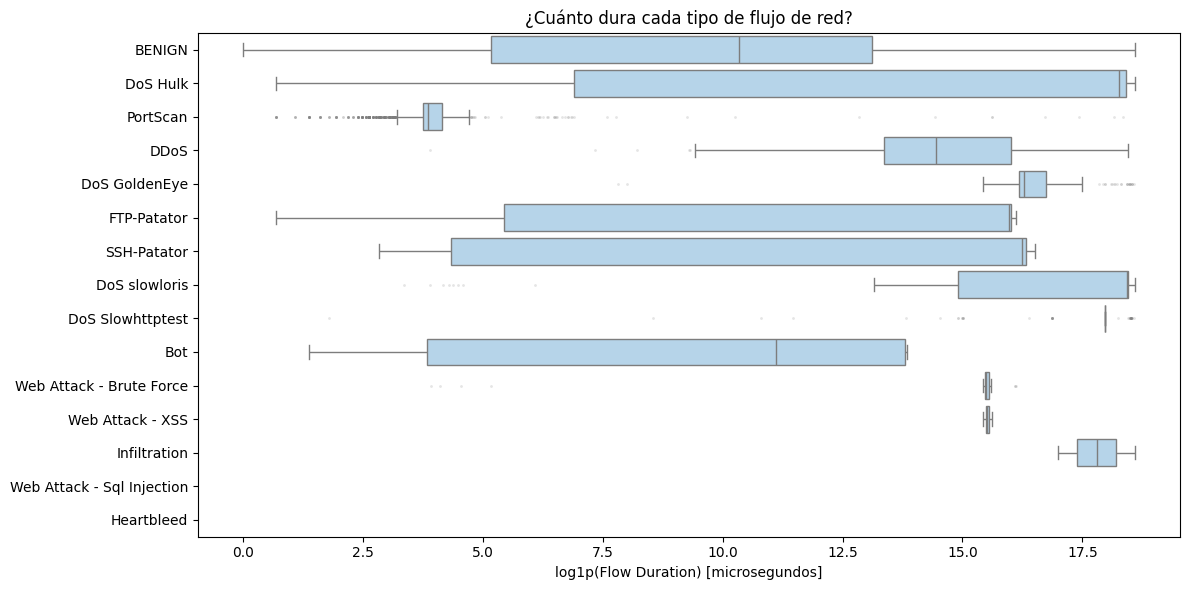

In [ ]:
# Boxplot de duración por clase (escala log)
muestra = df_clean.sample(min(50_000, len(df_clean)), random_state=42).copy()
muestra['log_duration'] = np.log1p(muestra['Flow Duration'].clip(lower=0))

orden = df_clean['Label'].value_counts().index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=muestra, x='log_duration', y='Label', order=orden,
            color=COLOR_NEUTRO,
            flierprops={'marker': '.', 'alpha': 0.2, 'markersize': 2})
ax.set_xlabel('log1p(Flow Duration) [microsegundos]')
ax.set_ylabel('')
ax.set_title('¿Cuánto dura cada tipo de flujo de red?')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_duracion_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

**Respuestas**

**¿Cómo varía la duración del flujo según el tipo de ataque?**

Los ataques de tipo DoS generan flujos muy cortos porque buscan saturar el servidor con conexiones rápidas y masivas. El tráfico BENIGN en cambio presenta duraciones muy variables, desde conexiones instantáneas hasta sesiones largas de navegación o descarga. Esta diferencia en duración ya es una señal útil para el modelo.

**¿Todos los ataques tienen un patrón claro?**

No. Algunos como DoS Hulk o DDoS son fácilmente distinguibles por sus valores extremos. Otros como Botnet o Infiltration se solapan bastante con el tráfico normal, lo que los hace mucho más difíciles de detectar con una sola variable.

**¿Qué clases son más fáciles de separar visualmente?**

DoS Hulk, DDoS y PortScan muestran distribuciones claramente distintas al tráfico BENIGN. Heartbleed e Infiltration tienen tan pocas muestras que sus distribuciones son poco representativas.

## 4.3 Correlación entre Variables

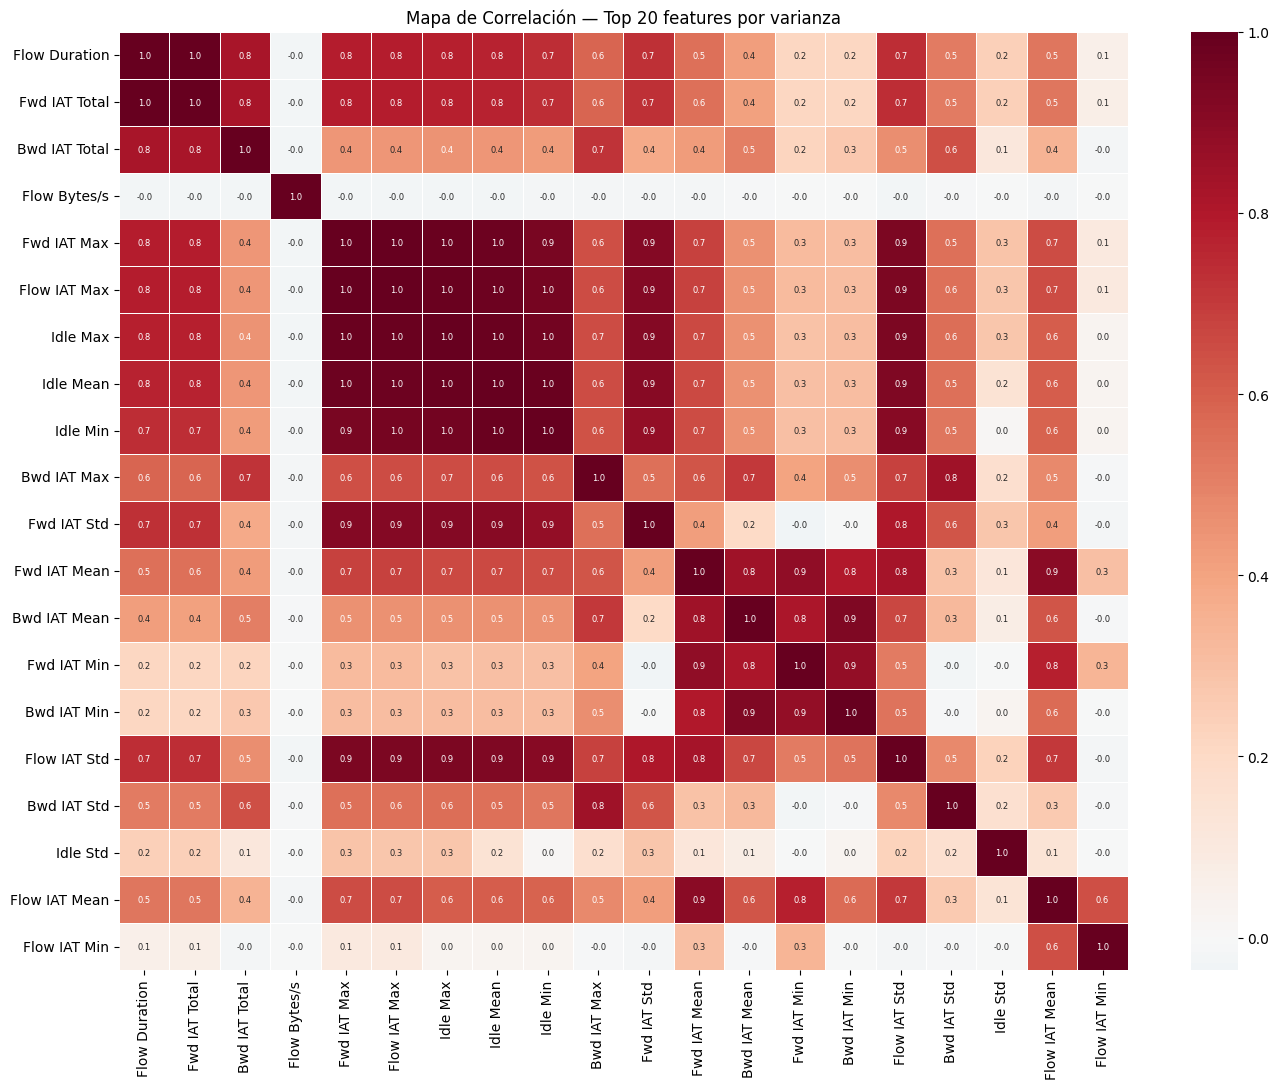

In [ ]:
# Heatmap de correlación — Top 20 variables por varianza
varianza   = df_clean[num_cols].var().sort_values(ascending=False)
top20_cols = varianza.head(20).index.tolist()
corr_matrix = df_clean[top20_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0,
            annot=True, fmt='.1f', annot_kws={'size': 6},
            linewidths=0.5, ax=ax)
ax.set_title('Mapa de Correlación — Top 20 variables por varianza', fontsize=12)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

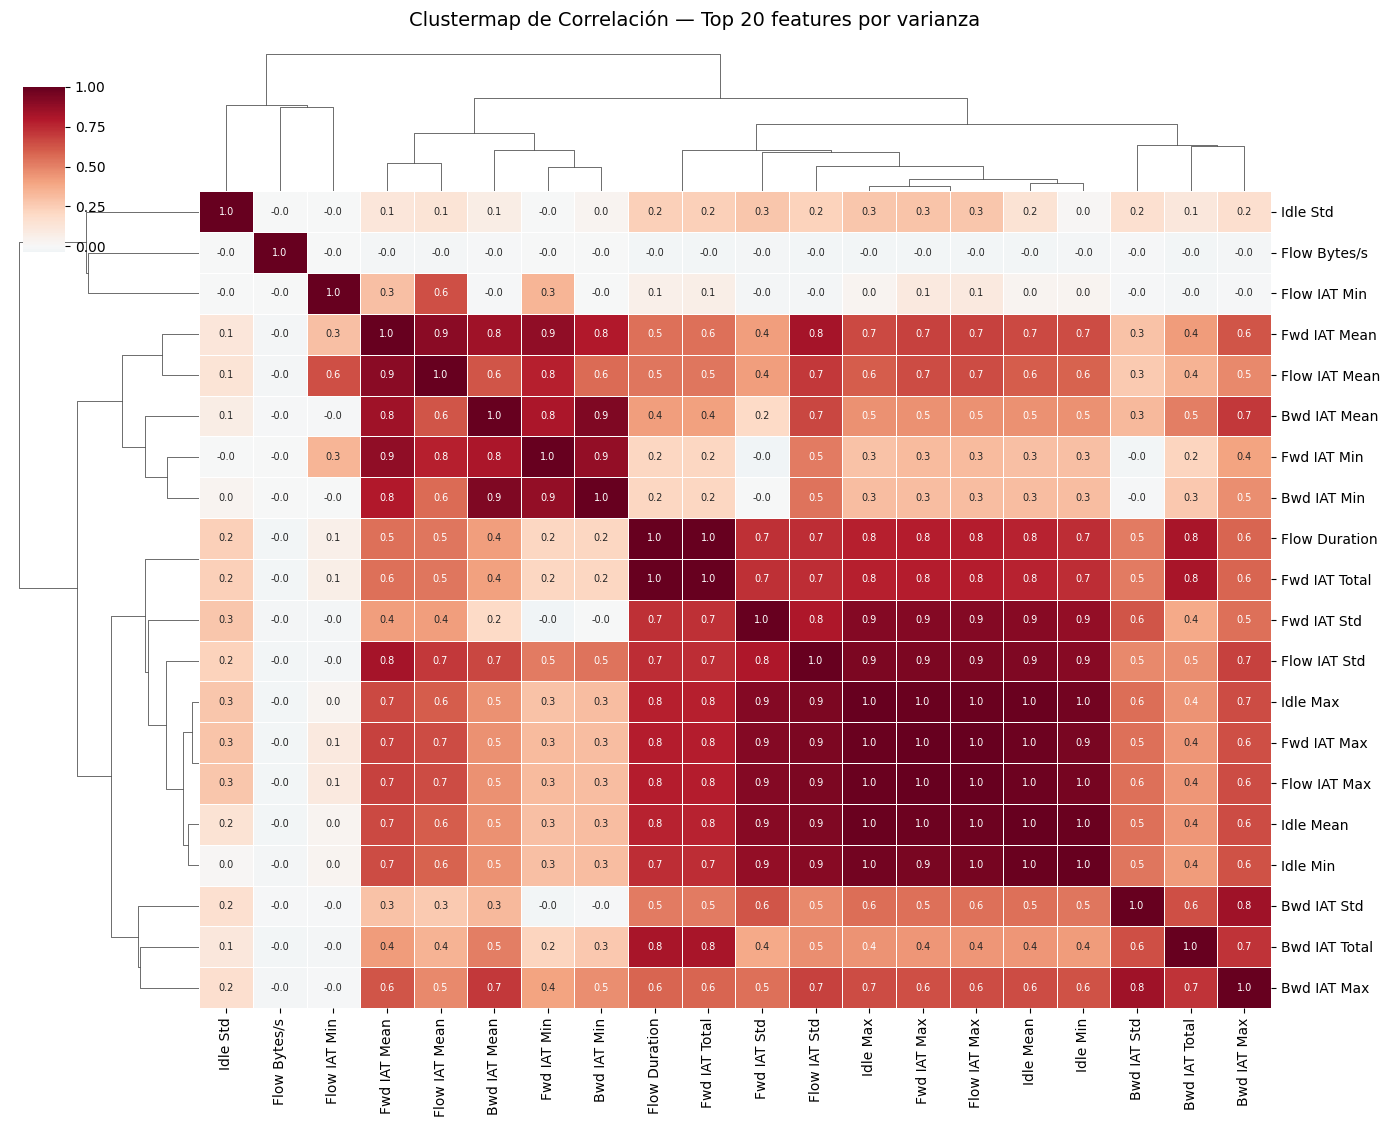

In [ ]:
# Clustermap de correlación — Top 20 variables por varianza
varianza = df_clean[num_cols].var().sort_values(ascending=False)
top20_cols = varianza.head(20).index.tolist()
corr_matrix = df_clean[top20_cols].corr()

# Generar el Clustermap
g = sns.clustermap(corr_matrix,
                   cmap='RdBu_r',
                   center=0,
                   annot=True,
                   fmt='.1f',
                   annot_kws={'size': 7},
                   linewidths=0.5,
                   figsize=(14, 11),
                   dendrogram_ratio=(0.15, 0.15), # Tamaño de los dendrogramas
                   cbar_pos=(0.02, 0.8, 0.03, 0.15)) # Posición de la barra de color

# Ajustar el título (se hace a través de la figura del objeto cluster)
g.fig.suptitle('Clustermap de Correlación — Top 20 variables por varianza', fontsize=14, y=1.02)

# Guardar y mostrar
plt.savefig(f'{CHECKPOINT_DIR}/clustermap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Pares con correlación muy alta
umbral = 0.95   # correlación > 95 % muy probablemente redundantes

alta_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= umbral:
            alta_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlación': round(val, 3)
            })

if alta_corr:
    print(f'Pares con correlación ≥ {umbral}:')
    print(pd.DataFrame(alta_corr).to_string(index=False))
else:
    print(f'✅ No se encontraron pares con correlación ≥ {umbral} entre el top 20.')

Pares con correlación ≥ 0.95:
    Feature 1     Feature 2  Correlación
Flow Duration Fwd IAT Total         1.00
  Fwd IAT Max  Flow IAT Max         1.00
  Fwd IAT Max      Idle Max         0.99
  Fwd IAT Max     Idle Mean         0.98
 Flow IAT Max      Idle Max         0.99
 Flow IAT Max     Idle Mean         0.98
 Flow IAT Max      Idle Min         0.95
     Idle Max     Idle Mean         0.99
     Idle Max      Idle Min         0.96
    Idle Mean      Idle Min         0.99


**Respuestas**

**¿Por qué la analizamos la correlación?**

La correlación mide cuánto se mueven juntas dos variables. Si dos variables tienen correlación cercana a 1 o -1, prácticamente contienen la misma información, y mantener ambas no mejora el modelo pero sí lo enlentece.

**¿Qué pares de variables están muy correlacionados?**

Las métricas de paquetes forward y backward tienden a correlacionarse fuertemente entre sí, al igual que las distintas medidas de longitud de paquete (mínimo, máximo, media). Esto tiene sentido: si una conexión transfiere muchos bytes, tanto el promedio como el máximo de longitud de paquete van a ser altos al mismo tiempo.

**¿Eliminamos las variables correlacionadas?**

No, solo las identificamos. La eliminación se hace en la fase de modelado, donde podremos medir el impacto real de cada variable.

**¿Hay correlaciones negativas relevantes?**

En general son pocas y débiles en este dataset. Las métricas de red tienden a correlacionarse positivamente entre sí porque todas crecen cuando el volumen de tráfico aumenta.

## 4.4 ¿Qué Distingue Cada Tipo de Ataque?

In [ ]:
# Mediana de las top 10 variables por clase
# Esto muestra qué valores son típicos de cada tipo de ataque

# Elegir variables de red más interpretables
features_interes = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Max',
    'Bwd Packet Length Max', 'Flow IAT Mean', 'Fwd IAT Mean', 'Packet Length Mean'
]

# Filtrar solo las que existen después de la limpieza
features_interes = [f for f in features_interes if f in df_clean.columns]

tabla_mediana = df_clean.groupby('Label')[features_interes].median().round(1)

# Transponer para leer mejor (feature × clase)
pd.set_option('display.max_columns', None)
print('Mediana por clase para variables clave:')
print(tabla_mediana.to_string())

Mediana por clase para variables clave:
                            Flow Duration  Total Fwd Packets  Total Backward Packets  Flow Bytes/s  Flow Packets/s  Fwd Packet Length Max  Bwd Packet Length Max  Flow IAT Mean  Fwd IAT Mean  Packet Length Mean
Label                                                                                                                                                                                                            
BENIGN                           31003.00               2.00                    2.00       5149.80          122.50                  40.00                  84.00       10591.00          4.00               58.60
Bot                              70974.00               3.00                    3.00       5022.00          101.30                   6.00                   6.00       11512.20      22994.70                6.00
DDoS                           1878984.00               4.00                    4.00        160.10            2.60      

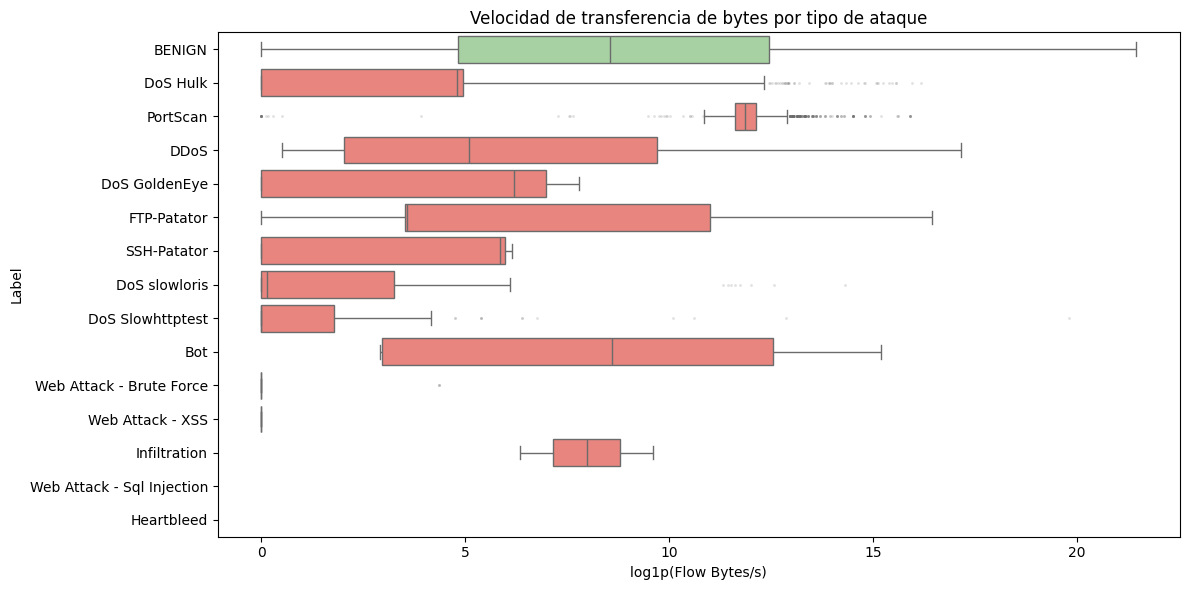

In [ ]:
# Boxplot: Flow Bytes/s por tipo de ataque
# Flow Bytes/s es una de las variables más útiles para detectar DoS/DDoS

if 'Flow Bytes/s' in df_clean.columns:
    muestra = df_clean.sample(min(50_000, len(df_clean)), random_state=42).copy()
    muestra['log_bytes_s'] = np.log1p(muestra['Flow Bytes/s'].clip(lower=0))

    orden = df_clean['Label'].value_counts().index
    colors_list = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in orden]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=muestra, x='log_bytes_s', y='Label', order=orden,
                palette=dict(zip(orden, colors_list)),
                flierprops={'marker':'.','alpha':0.2,'markersize':2})
    ax.set_xlabel('log1p(Flow Bytes/s)')
    ax.set_title('Velocidad de transferencia de bytes por tipo de ataque')
    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/grafico_bytes_por_clase.png', dpi=150, bbox_inches='tight')
    plt.show()

**Respuestas**

**¿Qué variables distinguen mejor cada tipo de ataque?**

`Flow Bytes/s` y `Flow Packets/s` son las más discriminativas. Los ataques DoS y DDoS generan valores extremadamente altos en ambas, mientras que PortScan muestra muchos paquetes pero muy pocos bytes, porque solo sondea puertos sin transferir datos reales.

**¿Hay ataques difíciles de separar del tráfico normal?**

Sí. Botnet e Infiltration tienen medianas muy similares al tráfico BENIGN en casi todas las variables. Esto significa que el modelo va a necesitar combinar varias variables a la vez para detectarlos, y aun así serán los de peor rendimiento.

**¿Qué nos dice la duración del flujo?**

`Flow Duration` varía mucho entre tipos de ataque. DoS Hulk genera flujos muy cortos y masivos, mientras que conexiones benignas como navegación o descargas pueden durar mucho más. Esta variable sola ya aporta información útil al modelo.

**¿Qué aprendemos de los tiempos entre paquetes?**

`Flow IAT Mean` y `Fwd IAT Mean` (tiempo promedio entre paquetes consecutivos) son bajos en ataques de fuerza bruta y DoS, donde los paquetes se envían lo más rápido posible. En tráfico normal estos tiempos son más irregulares y espaciados.

**Conclusión**

Ninguna feature por sí sola separa perfectamente todas las clases, pero la combinación de métricas de volumen, duración y timing permite al modelo construir reglas de decisión efectivas para la mayoría de los ataques.

## 4.5 Análisis del Desbalance de Clases

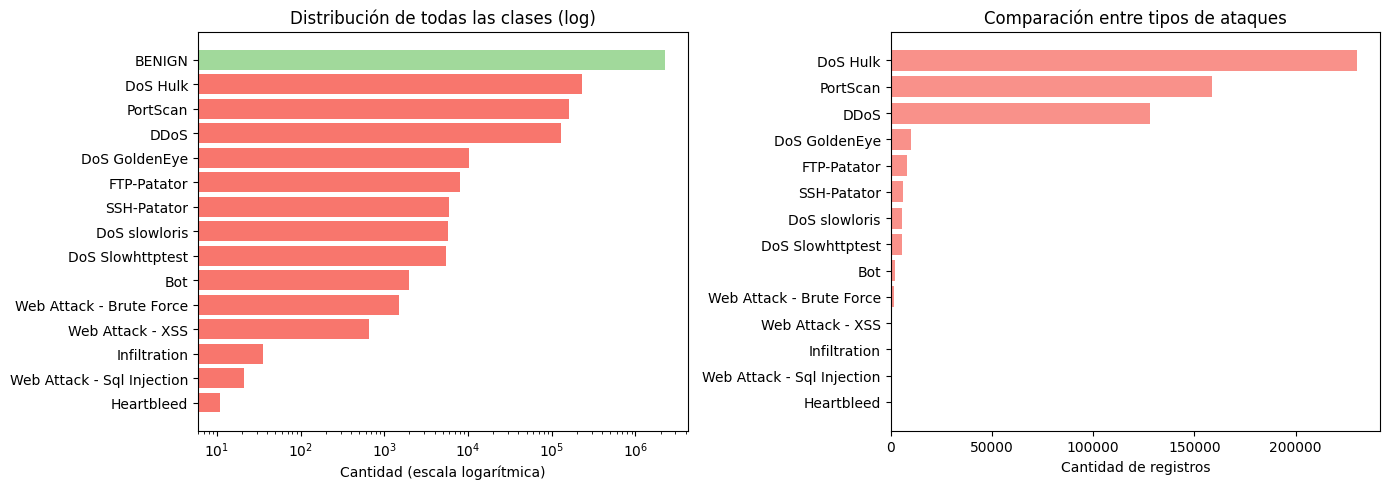


Ratio de desbalance (BENIGN / clase_más_rara):
 Clase más rara: Heartbleed (11 registros)
 BENIGN: 2,271,320 registros
 Ratio: 206484 : 1


In [ ]:
# Visualizar el desbalance
counts = df_clean['Label'].value_counts()

# Separar benigno de ataques
benign_count = counts.get('BENIGN', 0)
attack_counts = counts.drop('BENIGN', errors='ignore')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: todos juntos (escala log para ver las clases raras)
axes[0].barh(counts.index, counts.values,
             color=[COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in counts.index])
axes[0].set_xscale('log')
axes[0].set_xlabel('Cantidad (escala logarítmica)')
axes[0].set_title('Distribución de todas las clases (log)')
axes[0].invert_yaxis()

# Gráfico 2: solo los ataques, para comparar entre ellos
axes[1].barh(attack_counts.index, attack_counts.values, color=COLOR_ATAQUE, alpha=0.8)
axes[1].set_xlabel('Cantidad de registros')
axes[1].set_title('Comparación entre tipos de ataques')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_desbalance_clases.png', dpi=150, bbox_inches='tight')
plt.show()

# Ratio de desbalance
print(f'\nRatio de desbalance (BENIGN / clase_más_rara):')
min_clase = counts.min()
print(f' Clase más rara: {counts.idxmin()} ({min_clase:,} registros)')
print(f' BENIGN: {benign_count:,} registros')
print(f' Ratio: {benign_count / min_clase:.0f} : 1')


**Respuestas**

**¿Qué tan grave es el desbalance?**

BENIGN representa aproximadamente el 80 % del dataset, mientras que clases como Heartbleed o Infiltration tienen menos del 0.01 % de los registros.

El ratio entre la clase más frecuente y la más rara es 206484 : 1, significa que por cada vez que tu modelo vea un ejemplo de Heartbleed, habrá visto más de doscientas mil instancias de tráfico benigno.

**¿Por qué es un problema?**

Un modelo entrenado sin corrección aprende rápidamente que "predecir siempre benigno" le da un accuracy del 80 %, sin detectar ni un solo ataque. Esto es exactamente lo opuesto a lo que necesita un IDS.

**¿Qué estrategia vamos a usar?**

El primer paso es entrenar con `class_weight='balanced'`, que le indica al modelo que penalice más los errores cometidos en las clases raras. Para las clases con muy pocas muestras (Heartbleed, Infiltration) aplicaremos SMOTE, una técnica que genera registros sintéticos interpolando entre muestras existentes. Finalmente, ajustaremos el umbral de decisión del modelo para maximizar el Recall en los ataques más peligrosos.

## 4.6 ¿Cómo se Distribuyen las Variables Más Importantes?

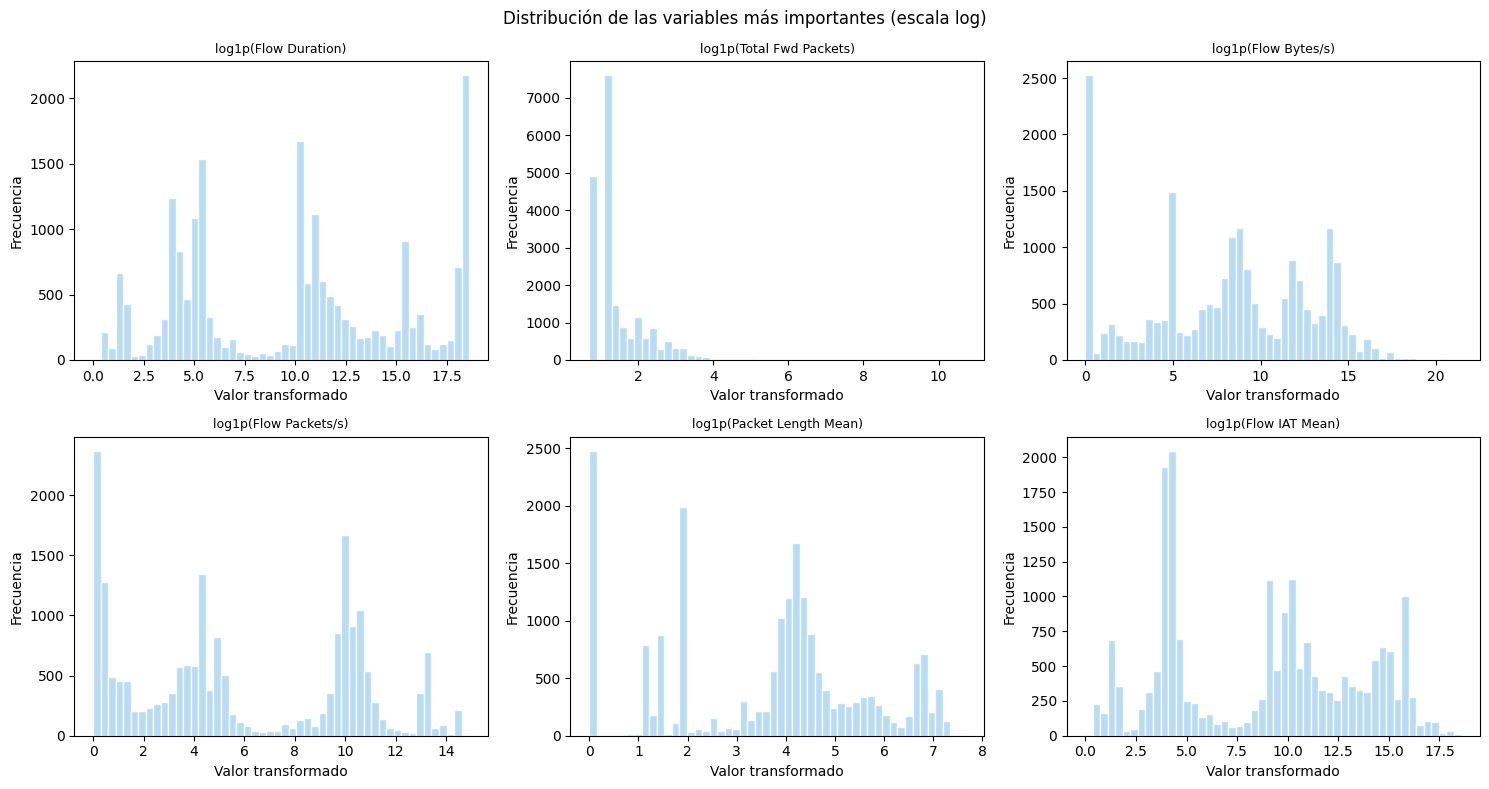

In [ ]:
# Histogramas de las 6 variables más relevantes para un IDS
features_plot = [f for f in ['Flow Duration', 'Total Fwd Packets',
                              'Flow Bytes/s', 'Flow Packets/s',
                              'Packet Length Mean', 'Flow IAT Mean']
                 if f in df_clean.columns]

muestra = df_clean.sample(min(20_000, len(df_clean)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_plot):
    # Aplicar log1p para comprimir la escala
    valores = np.log1p(muestra[col].clip(lower=0))
    axes[i].hist(valores, bins=50, color=COLOR_NEUTRO, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'log1p({col})', fontsize=9)
    axes[i].set_xlabel('Valor transformado')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de las variables más importantes (escala log)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

**Respuestas**

**¿Tienen distribuciones normales?**

No. Casi ninguna variable sigue una distribución normal. La mayoría tienen forma de "J" o bimodal, con una acumulación de valores bajos y una cola larga hacia valores altos.

**¿Por qué es importante saberlo?**

Algunos algoritmos de machine learning (como regresión logística o SVM) funcionan mejor cuando los datos tienen distribución normal. Para este dataset, algoritmos basados en árboles (como Random Forest o XGBoost) serán más adecuados ya que no asumen ninguna distribución.

## 4.7 ¿Los Ataques Generan Más Tráfico en una Dirección?

¿La relación entre paquetes enviados (forward) y recibidos (backward) varía según el tipo de ataque?

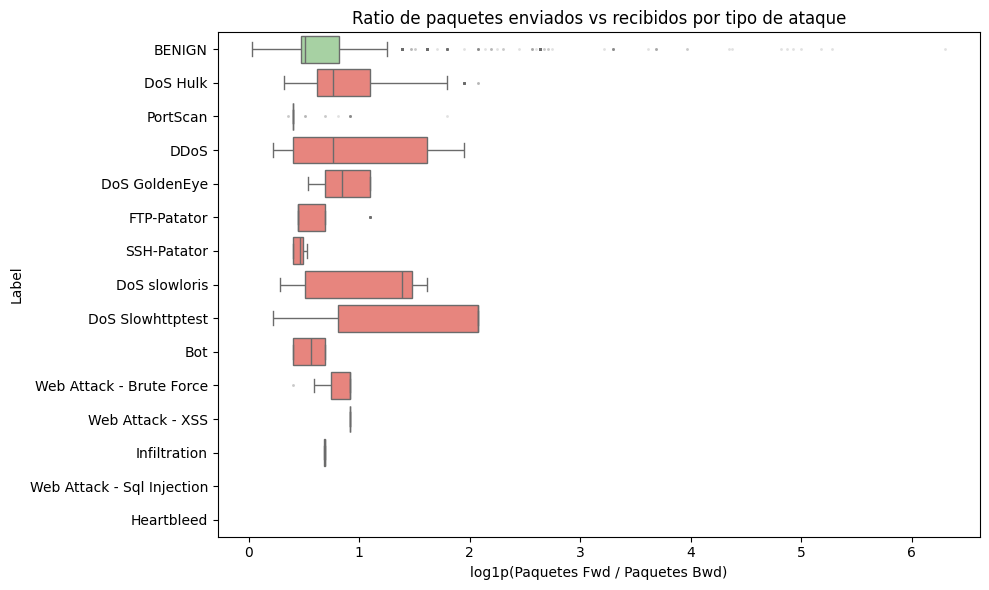

In [ ]:
# Crear columna de ratio fwd/bwd (evitar división por cero)
if 'Total Fwd Packets' in df_clean.columns and 'Total Backward Packets' in df_clean.columns:
    muestra = df_clean.sample(min(30_000, len(df_clean)), random_state=42).copy()

    # Ratio: paquetes enviados / (paquetes recibidos + 1)
    muestra['ratio_fwd_bwd'] = muestra['Total Fwd Packets'] / (muestra['Total Backward Packets'] + 1)
    muestra['log_ratio'] = np.log1p(muestra['ratio_fwd_bwd'])

    orden = df_clean['Label'].value_counts().index
    colors_list = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in orden]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=muestra, x='log_ratio', y='Label', order=orden,
                palette=colors_list,
                flierprops={'marker': '.', 'alpha': 0.2, 'markersize': 2})
    ax.set_xlabel('log1p(Paquetes Fwd / Paquetes Bwd)')
    ax.set_title('Ratio de paquetes enviados vs recibidos por tipo de ataque')
    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/grafico_ratio_fwd_bwd.png', dpi=150, bbox_inches='tight')
    plt.show()

**Respuestas**

**¿Qué nos dice este ratio?**

Un ratio alto (muchos paquetes enviados, pocos recibidos) indica que el atacante está inundando al servidor sin esperar respuesta. Esto es típico de ataques DoS/DDoS.

**¿PortScan tiene un patrón especial?**

Sí. PortScan genera muchos paquetes pequeños en dirección forward (sondeos) pero casi no recibe respuestas, lo que produce un ratio muy alto y característico.

**¿El tráfico BENIGN tiene un ratio equilibrado?**

Generalmente sí, porque en una conexión normal ambas partes intercambian información en ambas direcciones.

## 4.8 ¿Qué variables son las más diferentes entre Benigno y Ataque?

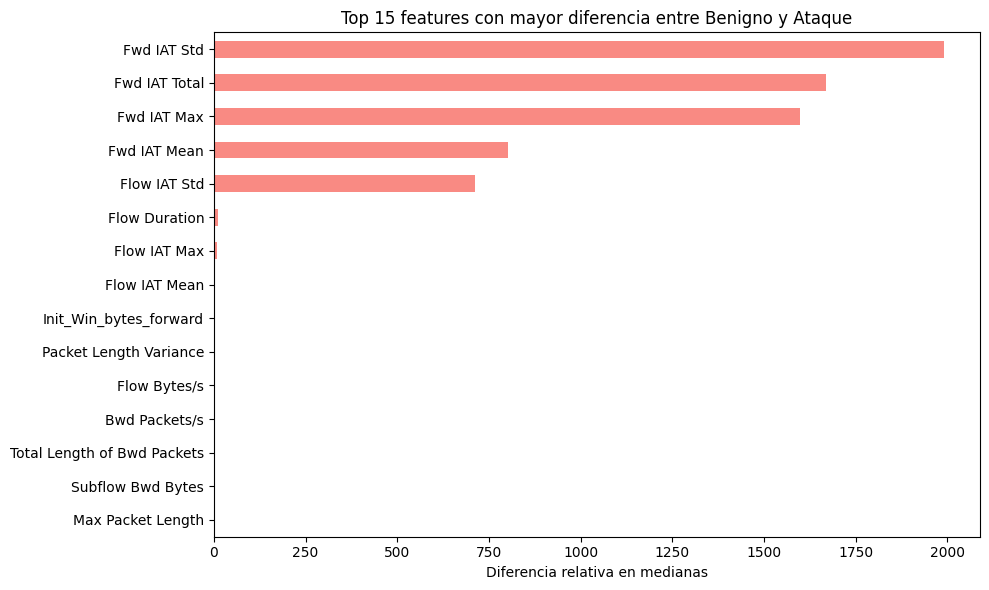

Top 15 features más discriminativas:
Fwd IAT Std                    1989.798482
Fwd IAT Total                  1669.200000
Fwd IAT Max                    1599.600000
Fwd IAT Mean                    801.900000
Flow IAT Std                    711.516564
Flow Duration                    10.209054
Flow IAT Max                      7.994344
Flow IAT Mean                     3.399103
Init_Win_bytes_forward            1.310924
Packet Length Variance            0.982690
Flow Bytes/s                      0.971777
Bwd Packets/s                     0.959173
Subflow Bwd Bytes                 0.946565
Total Length of Bwd Packets       0.946565
Max Packet Length                 0.923077


In [ ]:
# Comparar mediana de cada feature entre BENIGN y todos los ataques juntos
df_bin = df_clean.copy()
df_bin['es_ataque'] = (df_bin['Label'] != 'BENIGN').astype(int)

mediana_benigno = df_bin[df_bin['es_ataque'] == 0][num_cols].median()
mediana_ataque = df_bin[df_bin['es_ataque'] == 1][num_cols].median()

# Diferencia relativa (cuánto cambia en términos porcentuales)
diff_relativa = ((mediana_ataque - mediana_benigno) / (mediana_benigno.abs() + 1)).abs()
diff_relativa = diff_relativa.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
diff_relativa.sort_values().plot(kind='barh', ax=ax, color=COLOR_ATAQUE, alpha=0.85)
ax.set_xlabel('Diferencia relativa en medianas')
ax.set_title('Top 15 variables con mayor diferencia entre Benigno y Ataque')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_diferencia_benigno_ataque.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 variables más discriminativas:')
print(diff_relativa.to_string())

**Respuestas**

**¿Qué nos dice este gráfico?**

Las barras más largas indican las variables donde la diferencia entre tráfico benigno y tráfico de ataque es mayor. Son las candidatas más importantes para entrenar el modelo.

**¿Cómo se interpreta la diferencia relativa?**

Si `Flow Bytes/s` tiene diferencia relativa de 5.0, significa que los ataques tienen en promedio 5 veces más bytes por segundo que el tráfico normal. Es una diferencia enorme y muy útil para clasificar.

**¿Esto reemplaza a un modelo de machine learning?**

No. Este análisis nos ayuda a entender los datos y seleccionar variables relevantes, pero no podemos establecer reglas exactas de corte para cada feature. El modelo aprenderá a combinar todas estas diferencias de forma automática.

## 4.9 Análisis de las Clases Raras

In [ ]:
# Identificar clases raras (menos de 1000 registros)
counts = df_clean['Label'].value_counts()
clases_raras = counts[counts < 1000].index.tolist()

print('Clases con menos de 1000 muestras:')
for clase in clases_raras:
    print(f"- {clase}: {counts[clase]} registros")

if clases_raras:
    # Mostrar estadísticas de las clases raras
    df_raras = df_clean[df_clean['Label'].isin(clases_raras)]

    features_ver = [f for f in ['Flow Duration', 'Total Fwd Packets',
                                 'Flow Bytes/s', 'Packet Length Mean']
                    if f in df_clean.columns]

    for clase in clases_raras:
        print(f"\n>>> Estadísticas de la clase rara: {clase}")
        # Seleccionamos solo la clase actual y transponemos ( .T ) para leer mejor
        stats = df_raras[df_raras['Label'] == clase][features_ver].describe().T
        print(stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2).to_string())
        print(' ')

Clases con menos de 1000 muestras:
- Web Attack - XSS: 652 registros
- Infiltration: 36 registros
- Web Attack - Sql Injection: 21 registros
- Heartbleed: 11 registros

>>> Estadísticas de la clase rara: Web Attack - XSS
                    count        mean         std  min         25%        50%        75%          max
Flow Duration       652.0  6715357.09  9592863.04  4.0  5191744.75  5398909.5  5605595.0  70203058.00
Total Fwd Packets   652.0        7.90       30.78  1.0        3.00        3.0        3.0       212.00
Flow Bytes/s        652.0      103.35      571.77  0.0        0.00        0.0        0.0      4134.87
Packet Length Mean  652.0       23.48      124.85  0.0        0.00        0.0        0.0       755.47
 

>>> Estadísticas de la clase rara: Infiltration
                    count         mean          std    min          25%          50%           75%           max
Flow Duration        36.0  78407720.50  40396638.48  20.00  54516598.25  93188869.00  1.167758e+08  1.199

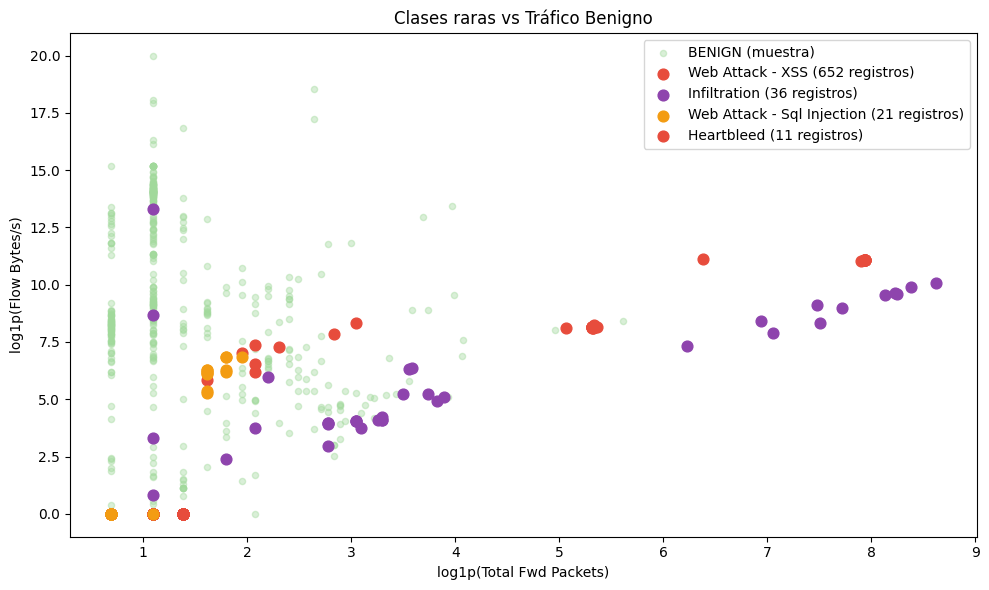

In [ ]:
# Comparar clases raras vs BENIGN en un scatter plot
if clases_raras and 'Flow Bytes/s' in df_clean.columns and 'Total Fwd Packets' in df_clean.columns:

    # Tomar muestra de BENIGN para comparar
    df_benign_muestra = df_clean[df_clean['Label'] == 'BENIGN'].sample(500, random_state=42)
    df_raras_muestra  = df_clean[df_clean['Label'].isin(clases_raras)]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(
        np.log1p(df_benign_muestra['Total Fwd Packets'].clip(lower=0)),
        np.log1p(df_benign_muestra['Flow Bytes/s'].clip(lower=0)),
        c=COLOR_BENIGNO, alpha=0.4, s=20, label='BENIGN (muestra)'
    )

    colores_raras = ['#E74C3C', '#8E44AD', '#F39C12']
    for i, clase in enumerate(clases_raras):
        sub = df_raras_muestra[df_raras_muestra['Label'] == clase]
        ax.scatter(
            np.log1p(sub['Total Fwd Packets'].clip(lower=0)),
            np.log1p(sub['Flow Bytes/s'].clip(lower=0)),
            c=colores_raras[i % len(colores_raras)], s=60,
            label=f'{clase} ({len(sub)} registros)', zorder=5
        )

    ax.set_xlabel('log1p(Total Fwd Packets)')
    ax.set_ylabel('log1p(Flow Bytes/s)')
    ax.set_title('Clases raras vs Tráfico Benigno')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/grafico_clases_raras.png', dpi=150, bbox_inches='tight')
    plt.show()


**Respuestas**

**¿Por qué analizar las clases raras por separado?**

Con tan pocas muestras, estas clases son difíciles de aprender para cualquier modelo. Entender sus características ayuda a decidir si vale la pena incluirlas o tratarlas como un caso especial.

**¿Se solapan con el tráfico benigno?**

Sí, en general estas clases raras tienen patrones muy similares al tráfico normal, lo que las hace especialmente difíciles de detectar. Son los ataques más "silenciosos".

**¿Qué hacemos con ellas en el modelado?**

Se pueden tratar de tres formas:
1. Incluirlas con técnicas de sobremuestreo como SMOTE
2. Combinarlas en una categoría genérica "ataque raro"
3. Crear un modelo binario separado solo para detectarlas.

## 4.10 Relación entre Variables Clave (Pairplot)

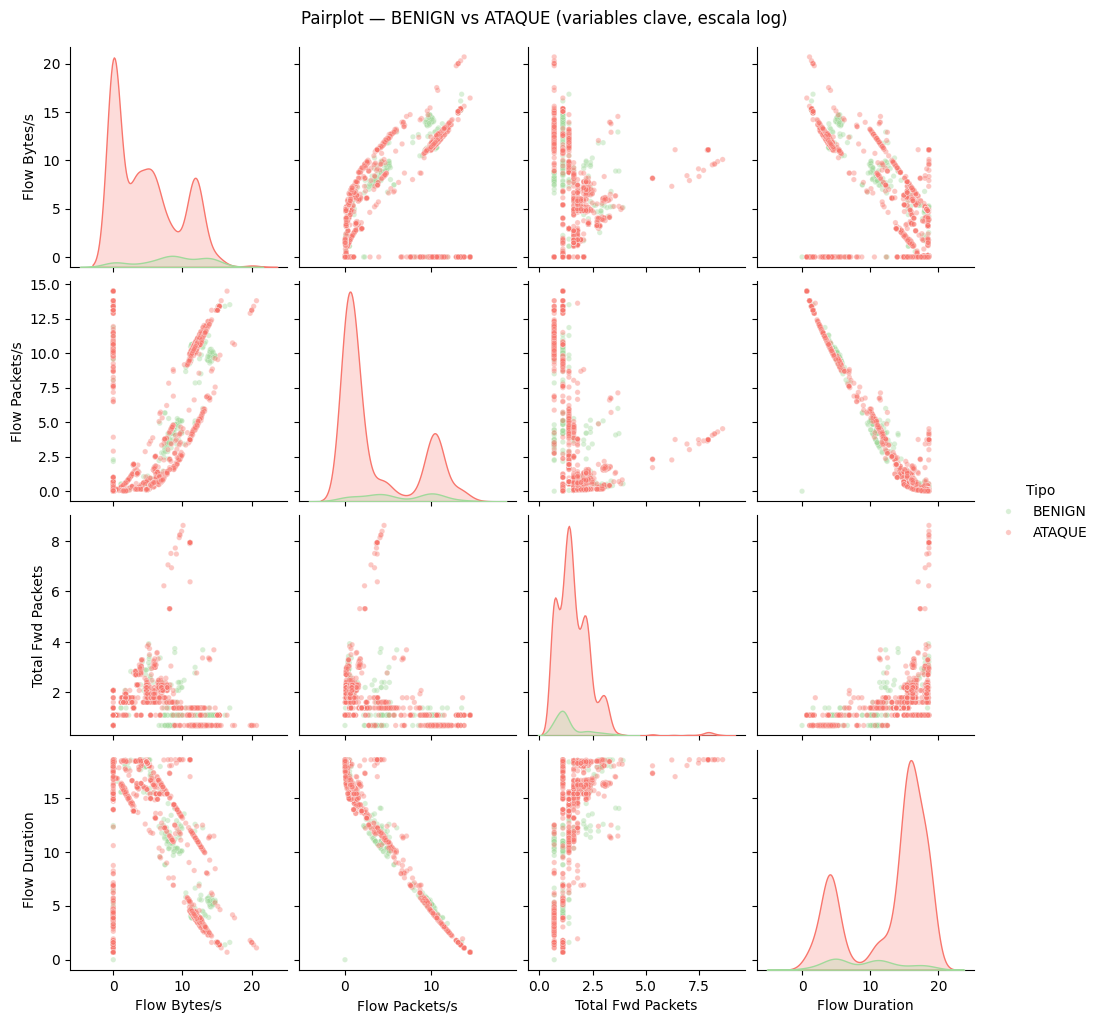

In [ ]:
# Pairplot con las 4 variables más importantes (muestra pequeña para no saturar)
features_pair = [f for f in ['Flow Bytes/s', 'Flow Packets/s',
                              'Total Fwd Packets', 'Flow Duration']
                 if f in df_clean.columns]

# Muestra estratificada: 200 por clase (máximo)
partes = []
for clase in df_clean['Label'].unique():
    sub = df_clean[df_clean['Label'] == clase]
    partes.append(sub.sample(min(200, len(sub)), random_state=42))
muestra_pair = pd.concat(partes, ignore_index=True)

# Aplicar log1p
for col in features_pair:
    muestra_pair[col] = np.log1p(muestra_pair[col].clip(lower=0))

# Simplificar etiquetas: BENIGN vs tipo de ataque
muestra_pair['Tipo'] = muestra_pair['Label'].apply(
    lambda x: 'BENIGN' if x == 'BENIGN' else 'ATAQUE'
)

pp = sns.pairplot(muestra_pair[features_pair + ['Tipo']],
                  hue='Tipo',
                  palette={'BENIGN': COLOR_BENIGNO, 'ATAQUE': COLOR_ATAQUE},
                  plot_kws={'alpha': 0.4, 's': 15},
                  diag_kind='kde')
pp.fig.suptitle('Pairplot — BENIGN vs ATAQUE (variables clave, escala log)', y=1.02, fontsize=12)
plt.savefig(f'{CHECKPOINT_DIR}/grafico_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


**Respuestas**

**¿Qué es un pairplot?**

Es una matriz de gráficos donde cada celda muestra la relación entre dos variables. En la diagonal aparece la distribución de cada variable por sí sola. Es útil para ver si las clases se separan visualmente.

**¿Se puede separar BENIGN de ATAQUE con dos variables?**

Parcialmente. Hay combinaciones (como `Flow Bytes/s` vs `Total Fwd Packets`) donde se ve cierta separación, pero en general las clases se solapan. Esto confirma que el modelo necesitará combinar muchas variables.


## 4.11 Resumen de Variables Numéricas por Clase

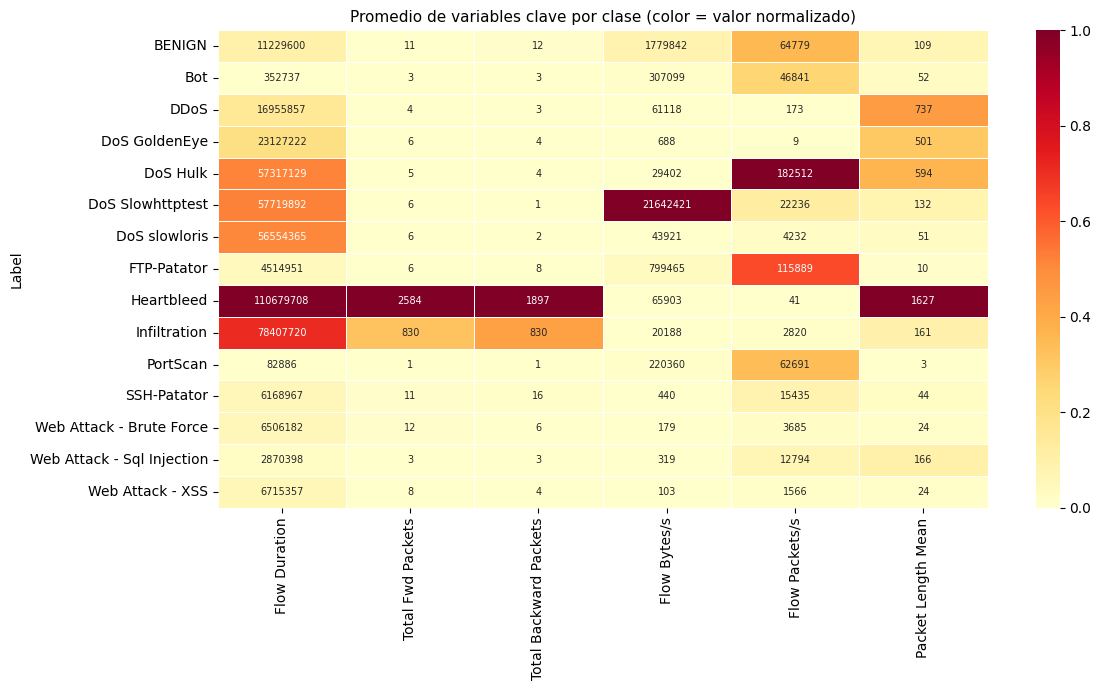

In [ ]:
# Tabla resumen: promedio de las variables más importantes por clase
features_resumen = [f for f in ['Flow Duration', 'Total Fwd Packets',
                                 'Total Backward Packets', 'Flow Bytes/s',
                                 'Flow Packets/s', 'Packet Length Mean']
                    if f in df_clean.columns]

resumen_clase = df_clean.groupby('Label')[features_resumen].mean().round(1)

# Normalizar para comparar en la misma escala (0 a 1)
resumen_norm = (resumen_clase - resumen_clase.min()) / (resumen_clase.max() - resumen_clase.min() + 1e-9)

# Heatmap de comparación
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(resumen_norm, cmap='YlOrRd', annot=resumen_clase.round(0),
            fmt='.0f', annot_kws={'size': 7}, linewidths=0.5, ax=ax)
ax.set_title('Promedio de variables clave por clase (color = valor normalizado)', fontsize=11)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_heatmap_clases.png', dpi=150, bbox_inches='tight')
plt.show()

**Respuestas**

**¿Cómo leer este heatmap?**

El color indica el valor relativo: rojo oscuro = valor alto para esa variable, amarillo = valor bajo. Los números dentro de cada celda muestran el promedio real.

**¿Qué patrones se ven claramente?**

DoS Hulk y DDoS tienen los valores más altos en `Flow Bytes/s` y `Flow Packets/s`, lo que confirma su naturaleza de saturación. PortScan tiene muchos `Total Fwd Packets` pero bajo `Packet Length Mean`.

**¿Por qué normalizamos los valores?**

Las variables tienen escalas muy distintas. Sin normalizar, `Flow Bytes/s` (con valores en millones) dominaría visualmente sobre `Total Fwd Packets` (con valores en decenas). La normalización permite comparar todas en la misma escala del 0 al 1.


---

# 5. Conclusión del EDA

Luego del análisis exploratorio completo sobre el dataset CIC-IDS2017, podemos sintetizar los principales hallazgos:

### Sobre la Calidad de los Datos
- El dataset original contenía **8 columnas constantes** (sin varianza), **5 columnas duplicadas** y **2 columnas con errores de medición graves** (valores negativos en duración), que fueron eliminadas.
- Se eliminaron ~2.867 filas con valores NaN (0.1% del total), provenientes de los infinitos en `Flow Bytes/s` y `Flow Packets/s`.
- El dataset limpio quedó con **~2.827.876 filas y ~64 columnas**.

### Sobre la Variable Objetivo
- El dataset está **severamente desbalanceado**: BENIGN representa el ~80% de los datos.
- El ratio entre la clase mayoritaria (BENIGN) y la más rara puede superar 1000:1.
- Heartbleed, Infiltration y Web Attack-Sql Injection son los ataques más difíciles de detectar por su baja frecuencia y similitud con tráfico normal.

### Sobre las Variables
- Las distribuciones son **no normales y muy sesgadas**: la mayoría de los flujos tienen valores bajos, pero los ataques generan valores extremos en varias métricas.
- Las variables más discriminativas son: `Flow Bytes/s`, `Flow Packets/s`, `Total Fwd Packets` y `Flow Duration`.
- Existe **alta correlación** entre grupos de variables relacionadas (métricas de paquetes, métricas de longitud), lo que sugiere que se puede reducir la dimensionalidad sin perder información relevante.

### Sobre los Patrones de Ataque
- **DoS/DDoS**: se distinguen por su enorme volumen de bytes y paquetes por segundo.
- **PortScan**: muchos paquetes forward, muy pocos bytes (solo sondea puertos).
- **Botnet e Infiltration**: muy similares al tráfico normal en todas las métricas, difíciles de detectar.
- **Brute Force**: tiempos entre paquetes muy bajos (`Flow IAT Mean` pequeño).


El EDA demostró que el problema es **tratable** con las herramientas correctas, pero que el desbalance de clases y la similitud de algunos ataques con tráfico normal son los principales desafíos a resolver en la fase de modelado.

## Información de sesión

In [23]:
session_info.show()